# SetUp

In [1]:
import mlflow
import os

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# import matplotlib.colors as mcolors
# import mpl_toolkits
import json

# import seaborn as sns
# import re
# from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
from scipy.interpolate import interp1d
import scipy.stats as stats

# from itertools import accumulate

In [2]:
# plt.rcParams.update({'font.size': 12})

In [3]:
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.family"] = "STIXGeneral"
plt.rcParams.update({"font.size": 14})

In [4]:
def legend(ax1, ax2=None, extra_lines=[], extra_labels=[], trim_labels=None, trim_labels2=None, loc='center left', bbox_to_anchor=(1, 0.5), **kwargs):
    lines, labels = ax1.get_legend_handles_labels()
    if trim_labels:
        labels = [label[:-trim_labels] for label in labels]
    if ax2 is not None:
        lines2, labels2 = ax2.get_legend_handles_labels()
    else:
        lines2, labels2 = [], []
    if trim_labels2:
        labels2 = [label[:-trim_labels2] for label in labels2]
        print(labels2)
    by_label = dict(zip(labels + labels2 + extra_labels, lines + lines2 + extra_lines))
    return plt.legend(by_label.values(), by_label.keys(), loc=loc, bbox_to_anchor=bbox_to_anchor, **kwargs)
    # plt.legend(lines + lines2, labels + labels2)


# colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

In [5]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colors = {i: color for i, color in enumerate(colors)}
colors["greedy"] = "tab:purple"
colors["restrict"] = "tab:orange"
colors["hsic"] = "tab:blue"
colors["random"] = "tab:green"
# rcolors = {
#     "greedy": "tab:purple",
#     "restrict": "tab:orange",
#     "hsic": "tab:blue",
#     "random": "tab:green",
# }
colors

{0: '#1f77b4',
 1: '#ff7f0e',
 2: '#2ca02c',
 3: '#d62728',
 4: '#9467bd',
 5: '#8c564b',
 6: '#e377c2',
 7: '#7f7f7f',
 8: '#bcbd22',
 9: '#17becf',
 'greedy': 'tab:purple',
 'restrict': 'tab:orange',
 'hsic': 'tab:blue',
 'random': 'tab:green'}

In [6]:
def DAG_to_pyvis(dag):
    # nt = Network('500px', '500px', directed=True, notebook=True, cdn_resources='remote')
    nt = Network(directed=True)

    for node in dag.nodes:
        size = dag.nodes[node]["size"]
        attrs = {
            "x": None,
            "y": None,
            "physics": True,
            "label": [],
            "color": size_to_color(size),
            "mass": 4,
            "shape": "box",
        }
        if node == "start":
            attrs.update({"x": 1.0, "y": 0.0, "physics": False})
        elif node == "end":
            attrs.update({"x": 15.0, "y": 0.0, "physics": False})
        nt.add_node(node, **attrs)
    for edge in dag.edges:
        prev_node, next_node = edge
        # nt.add_node(prev_node, label=prev_node, title=str(dag.nodes[prev_node]['size']))
        # nt.add_node(next_node, label=next_node, title=str(dag.nodes[next_node]['size']))
        nt.add_edge(prev_node, next_node, title=str(dag.edges[edge]["link"]))

    # print(nt.get_node('start'))
    # nt.toggle_physics(False)
    return nt


def size_to_color(size):
    cmap = mpl.cm.Reds
    norm = mpl.colors.Normalize(vmin=0, vmax=784)
    rgba = cmap(norm(size))
    return mpl.colors.rgb2hex(rgba)

In [7]:
def history_transform(history):
    x, y = [], []
    x_updated, y_updated = [], []
    for i, snapshot in history.items():
        step = int(i)
        for k, v in snapshot.items():
            if v == 2:
                x.append(step)
                y.append(k)
            if v == 1:
                x_updated.append(step)
                y_updated.append(k)
    return x, y, x_updated, y_updated

In [8]:
%cd "/home/tau/sdouka/codebase/experimental_grow/"
os.getcwd()

/home/tau/sdouka/codebase/experimental_grow


/home/tau/sdouka/miniconda3/envs/tiny/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


'/home/tau/sdouka/codebase/experimental_grow'

In [9]:
def get_runs(exp_name):
    experiment = client.get_experiment_by_name(exp_name)
    runs = client.search_runs([experiment.experiment_id])
    print("Number of runs", len(runs))
    runIds = {run.info.run_name: run.info.run_id for run in runs}
    return runIds

In [10]:
def get_logs(runIDs, artifacts=False):
    if not isinstance(runIDs, list):
        runIDs = [runIDs]
    print(runIDs)

    run_info = {}
    run_info_t = {}
    for runID in runIDs:
        # run_info["steps"].append({item.step: item.step for item in client.get_metric_history})
        retreived_run = client.get_run(runID)

        # Run name
        run_name = retreived_run.info.run_name
        # if "name" not in run_info:
        #     run_info["name"] = []
        #     run_info_t["name"] = []
        # run_info["name"].append(run_name)
        # run_info_t["name"].append(run_name)
        run_info[run_name] = {}
        run_info_t[run_name] = {}

        # Timing
        start_time = retreived_run.info.start_time
        try:
            run_info[run_name]["duration (ms)"] = retreived_run.info.end_time - start_time
            run_info_t[run_name]["duration (ms)"] = retreived_run.info.end_time - start_time
            run_info[run_name]["duration (s)"] = run_info[run_name]["duration (ms)"] / 1_000
            run_info_t[run_name]["duration (s)"] = run_info_t[run_name]["duration (ms)"] / 1_000
            run_info[run_name]["duration (h)"] = run_info[run_name]["duration (s)"] / 3_600
            run_info_t[run_name]["duration (h)"] = run_info_t[run_name]["duration (s)"] / 3_600
        except:
            print("Could not get duration of run")

        # Metrics
        for key in tqdm(retreived_run.data.metrics.keys()):
            if ("/node " in key) or ("/edge " in key) or ("/layer " in key):
                continue
            if (
                ("_utilization_" in key)
                or ("_percentage" in key)
                or ("network_" in key)
            ):
                continue

            # if key not in run_info[run_name]:
            #     run_info[run_name][key] = []
            #     run_info_t[run_name][key] = []
            metric_data = client.get_metric_history(runID, key)
            # run_info[key].append({item.step: item.value for item in metric_data})
            # run_info_t[key].append(
            #     {
            #         (item.timestamp - start_time) / 1_000: item.value
            #         for item in metric_data
            #     }
            # )
            run_info[run_name][key] = {item.step: item.value for item in metric_data}
            run_info_t[run_name][key] = {
                    (item.timestamp - start_time) / 1_000: item.value
                    for item in metric_data
                }

        # Artifacts
        if artifacts:
            try:
                # mlflow.artifacts.load_dict("mlflow-artifacts:/235085688558347327/e95c2ea3c22f44cb950829023dffc42e/artifacts/gh.json")
                artifact_uri = mlflow.artifacts.download_artifacts(
                    run_id=runID, artifact_path="gh.json"
                )
                with open(artifact_uri, "r") as f:
                    data = json.load(f)
                print(f"Got growth history for {artifact_uri}")
                # if "growth history" not in run_info:
                #     run_info["growth history"] = []
                # run_info["growth history"].append(data)
                run_info[run_name]["growth history"] = data
            except mlflow.MlflowException as err:
                print(f"[Run {runID}] {err}")
            except Exception as err:
                pass

    return run_info, run_info_t

In [11]:
client = mlflow.client.MlflowClient()
# mlflow.set_tracking_uri(uri="http://127.0.0.1:27027")

# MNIST

## Get Experiments

In [10]:
runIds = get_runs("HSICv2")
runIds

Number of runs 20


{'greedy_5': '8467ffc8130e44bf9f3a2308050cb870',
 'random_5': 'dcd7577307734e1a8befcfcee1c3b693',
 'restrict_5': '7a5aefa37b4841c18edb04fa6e7af01d',
 'hsic_5': 'f59eb4a63ae64e6ca440c395a1fafa57',
 'greedy_1': 'bdb77f394f3f4378af4d609c812c8111',
 'greedy_3': '442ce70067874a629f81f2207523fd71',
 'greedy_2': '8c38b571296e453680a3abc1b537f2d5',
 'greedy_4': '47378624e31745f2bdfd02ef0c2093b6',
 'restrict_1': '8e057833dcbc4f1db3f4c66a17ca3f37',
 'restrict_2': 'ad63e450810c43709e3fec163ac1d317',
 'restrict_3': '33e890cbb4cc4ffd87508d9d46b2b8b1',
 'restrict_4': '85141a0a2d234de893bc75202cd4b08e',
 'hsic_2': '5c4358fb5e134037875978096cbea18a',
 'hsic_1': '976d8cb8fb0449d58e4e8205e9fcc894',
 'hsic_4': '9f5b7e3824384d9d863d787f4e26cb74',
 'hsic_3': 'bee2b9fbf63648f7bf9717d4c8e09526',
 'random_1': '6a7fb6896ba14db8ac2b2d606ea80611',
 'random_2': '004526d05eb84068a4ae5106f1244d94',
 'random_4': 'deba01e4768f42d4829634820ae15271',
 'random_3': 'a38bb2d16e604cb986d0728b220abbfb'}

In [12]:
run_info, run_info_t = get_logs(list(runIds.values()))
list(run_info.keys())

['8467ffc8130e44bf9f3a2308050cb870', 'dcd7577307734e1a8befcfcee1c3b693', '7a5aefa37b4841c18edb04fa6e7af01d', 'f59eb4a63ae64e6ca440c395a1fafa57', 'bdb77f394f3f4378af4d609c812c8111', '442ce70067874a629f81f2207523fd71', '8c38b571296e453680a3abc1b537f2d5', '47378624e31745f2bdfd02ef0c2093b6', '8e057833dcbc4f1db3f4c66a17ca3f37', 'ad63e450810c43709e3fec163ac1d317', '33e890cbb4cc4ffd87508d9d46b2b8b1', '85141a0a2d234de893bc75202cd4b08e', '5c4358fb5e134037875978096cbea18a', '976d8cb8fb0449d58e4e8205e9fcc894', '9f5b7e3824384d9d863d787f4e26cb74', 'bee2b9fbf63648f7bf9717d4c8e09526', '6a7fb6896ba14db8ac2b2d606ea80611', '004526d05eb84068a4ae5106f1244d94', 'deba01e4768f42d4829634820ae15271', 'a38bb2d16e604cb986d0728b220abbfb']


100%|██████████| 319/319 [00:02<00:00, 154.77it/s]


['greedy_5',
 'random_5',
 'restrict_5',
 'hsic_5',
 'greedy_1',
 'greedy_3',
 'greedy_2',
 'greedy_4',
 'restrict_1',
 'restrict_2',
 'restrict_3',
 'restrict_4',
 'hsic_2',
 'hsic_1',
 'hsic_4',
 'hsic_3',
 'random_1',
 'random_2',
 'random_4',
 'random_3']

## Plots

### params vs complexity

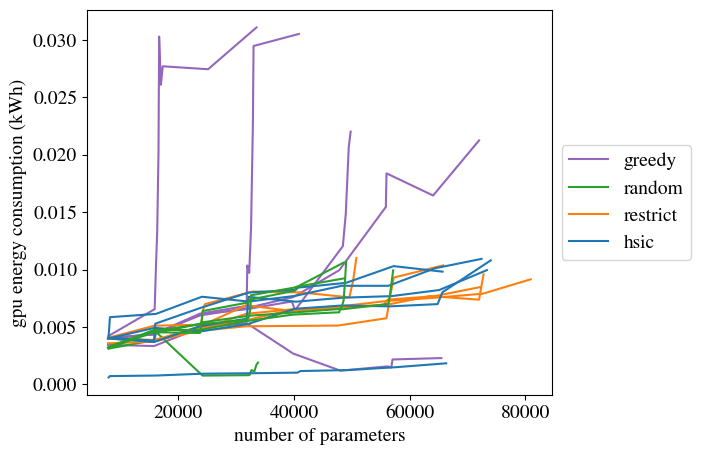

In [345]:
fig, ax1 = plt.subplots(figsize=(6, 5))
for name in run_info.keys():
    ax1.plot(
        list(run_info[name]["complexity/nb of parameters"].values())[:10],
        list(run_info[name]["codecarbon/gpu_energy"].values())[:10],
        label=f"{name}",
        color=colors[name[:-2]]
    )
    # ax1.plot(run_info["complexity/nb of parameters"][i].values(), list(accumulate(run_info["codecarbon/gpu_energy"][i].values())), "-", c=colors[1], label=f"cumulative")
legend(ax1, trim_labels=2)
ax1.set_xlabel("number of parameters")
ax1.set_ylabel("gpu energy consumption (kWh)")
# ax1.set_xscale("log")
plt.show()

### Random graphs

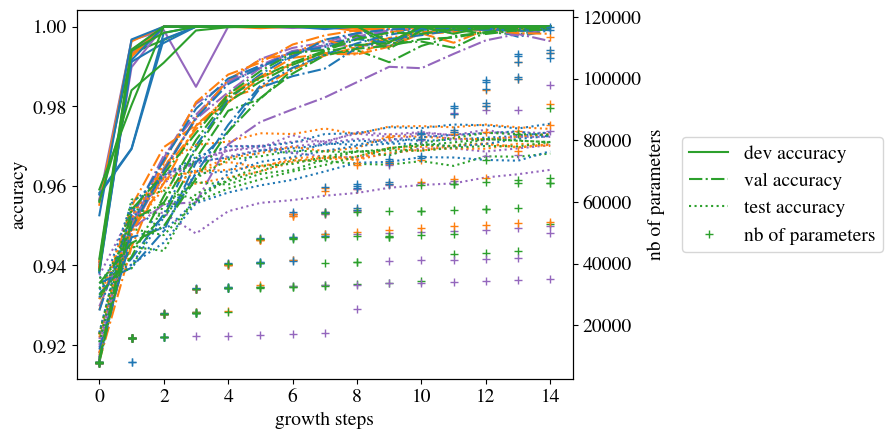

In [346]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
for name in run_info.keys():
    ax1.plot(
        run_info[name]["dev accuracy"].values(), "-", color=colors[name[:-2]], label="dev accuracy"
    )
    ax1.plot(
        run_info[name]["val accuracy"].values(),
        "-.",
        color=colors[name[:-2]],
        label="val accuracy",
    )
    ax1.plot(
        run_info[name]["test accuracy"].values(),
        ":",
        color=colors[name[:-2]],
        label="test accuracy",
    )
    ax2.plot(
        run_info[name]["complexity/nb of parameters"].values(),
        "+",
        color=colors[name[:-2]],
        label="nb of parameters",
    )
ax1.set_ylabel("accuracy")
ax2.set_ylabel("nb of parameters")
ax1.set_xlabel("growth steps")
plt.xlabel("steps")
legend(ax1, ax2, bbox_to_anchor=(1.2, 0.5))
plt.show()

In [355]:
# crop = 100  # 00
# fig, ax1 = plt.subplots()
# ax2 = ax1.twinx()
# for name in run_info.keys():
#     ax1.plot(
#         list(run_info[name]["Intermediate training/dev loss"].keys())[crop:],
#         list(run_info[name]["Intermediate training/dev loss"].values())[crop:],
#         "--",
#         color=colors[name[:-2]],
#         label="dev loss",
#     )
#     ax1.plot(
#         list(run_info[name]["Intermediate training/val loss"].keys())[crop:],
#         list(run_info[name]["Intermediate training/val loss"].values())[crop:],
#         "--",
#         color=colors[name[:-2]],
#         label="val loss",
#     )
#     ax2.plot(
#         list(run_info[name]["Intermediate training/dev accuracy"].keys())[crop:],
#         list(run_info[name]["Intermediate training/dev accuracy"].values())[crop:],
#         "-",
#         color=colors[name[:-2]],
#         label="dev accuracy",
#     )
#     ax2.plot(
#         list(run_info[name]["Intermediate training/val accuracy"].keys())[crop:],
#         list(run_info[name]["Intermediate training/val accuracy"].values())[crop:],
#         "-",
#         color=colors[name[:-2]],
#         label="val accuracy",
#     )
#     # ax1.scatter(run_info['test loss'][i].keys(), run_info['test loss'][i].values(), marker="*", color=colors[2], label="test loss")
#     epoch_len = list(run_info[name]["test accuracy"].keys())[0]
#     crop_acc = int(crop / epoch_len)
#     ax2.scatter(
#         list(run_info[name]["test accuracy"].keys())[crop_acc:],
#         list(run_info[name]["test accuracy"].values())[crop_acc:],
#         marker="*",
#         color=colors[name[:-2]],
#         label="test accuracy",
#     )
#     # ax2.scatter(run_info['growth val accuracy'][i].keys(), run_info['growth val accuracy'][i].values(), marker="*", color=colors[3], label="test accuracy")
#     # ax2.scatter(run_info['val accuracy'][i].keys(), run_info['val accuracy'][i].values(), marker="*", color=colors[4], label="test accuracy")
# ax1.set_ylabel("loss")
# ax2.set_ylabel("accuracy")
# ax1.set_xlabel("epochs")
# # ax1.set_xscale("symlog")
# legend(ax1, ax2)
# plt.show()

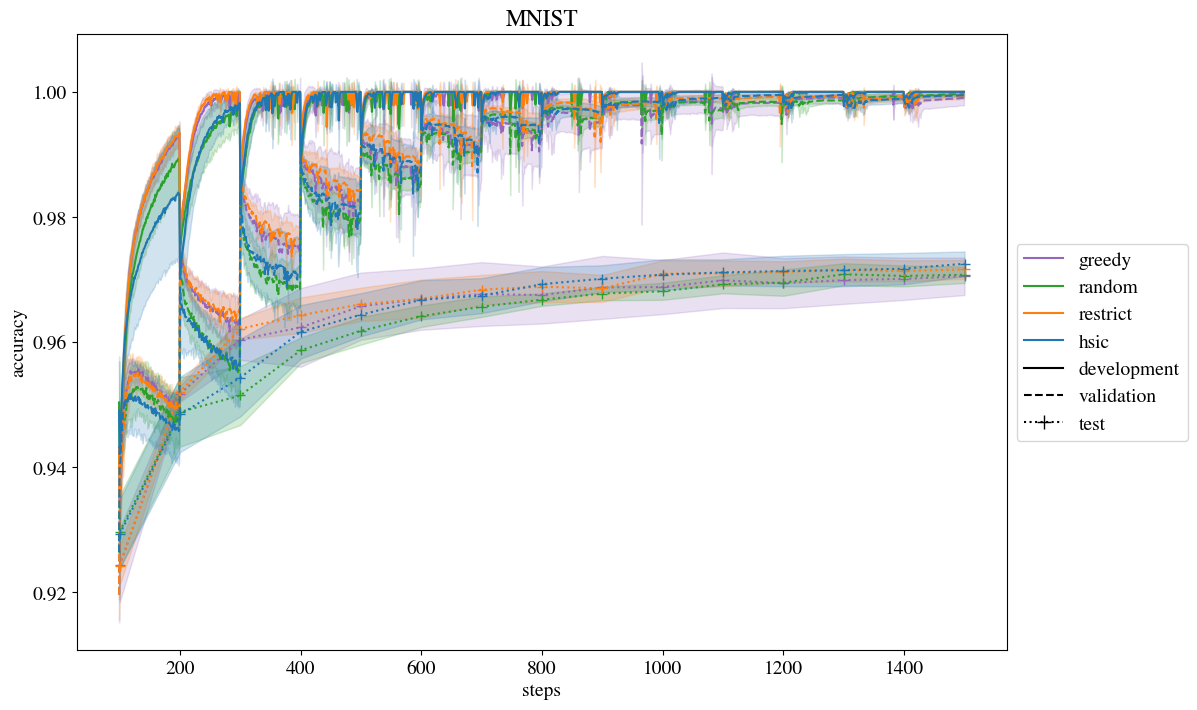

In [348]:
crop = 99
crop_end = 1_500
fig, ax1 = plt.subplots(figsize=(12,8))

dev_, val_, test_ = {}, {}, {}
for name in run_info.keys():
    _name = name[:-2]
    if _name not in dev_:
        dev_[_name] = []
        val_[_name] = []
        test_[_name] = []
    dev_[_name].append(list(run_info[name]["Intermediate training/dev accuracy"].values()))
    val_[_name].append(list(run_info[name]["Intermediate training/val accuracy"].values()))
    test_[_name].append(list(run_info[name]["test accuracy"].values()))

indx = list(run_info[name]["Intermediate training/dev accuracy"].keys())
indx_test = list(run_info[name]["test accuracy"].keys())
epoch_len = indx_test[0]
crop_start_acc, crop_end_acc = int(crop / epoch_len), int(crop_end / epoch_len)

dev_mean, dev_std, dev_conf = {}, {}, {}
val_mean, val_std, val_conf = {}, {}, {}
test_mean, test_std, test_conf = {}, {}, {}
for _name in dev_.keys():
    dev_mean[_name] = np.mean(dev_[_name], axis=0)
    dev_std[_name] = np.std(dev_[_name], axis=0)
    dev_conf[_name] = 1.96 * dev_std[_name] / np.sqrt(5)
    val_mean[_name] = np.mean(val_[_name], axis=0)
    val_std[_name] = np.std(val_[_name], axis=0)
    val_conf[_name] = 1.96 * val_std[_name] / np.sqrt(5)
    test_mean[_name] = np.mean(test_[_name], axis=0)
    test_std[_name] = np.std(test_[_name], axis=0)
    test_conf[_name] = 1.96 * test_std[_name] / np.sqrt(5)

    ax1.plot(
        indx[crop:crop_end],
        dev_mean[_name][crop:crop_end],
        color=colors[_name],
        label=_name,
        linestyle="-",
    )
    ax1.fill_between(
        indx[crop:crop_end],
        dev_mean[_name][crop:crop_end] - dev_conf[_name][crop:crop_end],
        dev_mean[_name][crop:crop_end] + dev_conf[_name][crop:crop_end],
        color=colors[_name],
        alpha=0.2,
    )

    ax1.plot(
        indx[crop:crop_end],
        val_mean[_name][crop:crop_end],
        color=colors[_name],
        # label=_name,
        linestyle="--",
    )
    ax1.fill_between(
        indx[crop:crop_end],
        # val_mean[_name][crop:crop_end] - val_std[_name][crop:crop_end],
        # val_mean[_name][crop:crop_end] + val_std[_name][crop:crop_end],
        val_mean[_name][crop:crop_end] - val_conf[_name][crop:crop_end],
        val_mean[_name][crop:crop_end] + val_conf[_name][crop:crop_end],
        color=colors[_name],
        alpha=0.2,
    )
    
    ax1.plot(
        indx_test[crop_start_acc:crop_end_acc],
        test_mean[_name][crop_start_acc:crop_end_acc],
        color=colors[_name],
        # label=_name,
        markersize=7,
        linestyle=":",
        marker="+",
    )
    ax1.fill_between(
        indx_test[crop_start_acc:crop_end_acc],
        test_mean[_name][crop_start_acc:crop_end_acc] - test_conf[_name][crop_start_acc:crop_end_acc],
        test_mean[_name][crop_start_acc:crop_end_acc] + test_conf[_name][crop_start_acc:crop_end_acc],
        color=colors[_name],
        alpha=0.2,
    )



myHandle = [
    Line2D([], [], color="k", markersize=10, linestyle="-"),
    Line2D([], [], color="k", markersize=10, linestyle="--"),
    Line2D([], [], color="k", markersize=10, linestyle=":", marker="+"),
]

legend(ax1, extra_lines=myHandle, extra_labels=["development", "validation", "test"])
plt.xlabel("steps")
plt.ylabel("accuracy")
plt.title("MNIST")
plt.show()

/tmp/ipykernel_4727/3069374579.py:51: RuntimeWarning: Mean of empty slice
  dev_mean = np.nanmean(interp_dev[_name], axis=0)
/tmp/ipykernel_4727/3069374579.py:70: RuntimeWarning: Mean of empty slice
  val_mean = np.nanmean(interp_val[_name], axis=0)
/tmp/ipykernel_4727/3069374579.py:88: RuntimeWarning: Mean of empty slice
  test_mean = np.nanmean(interp_test[_name], axis=0)


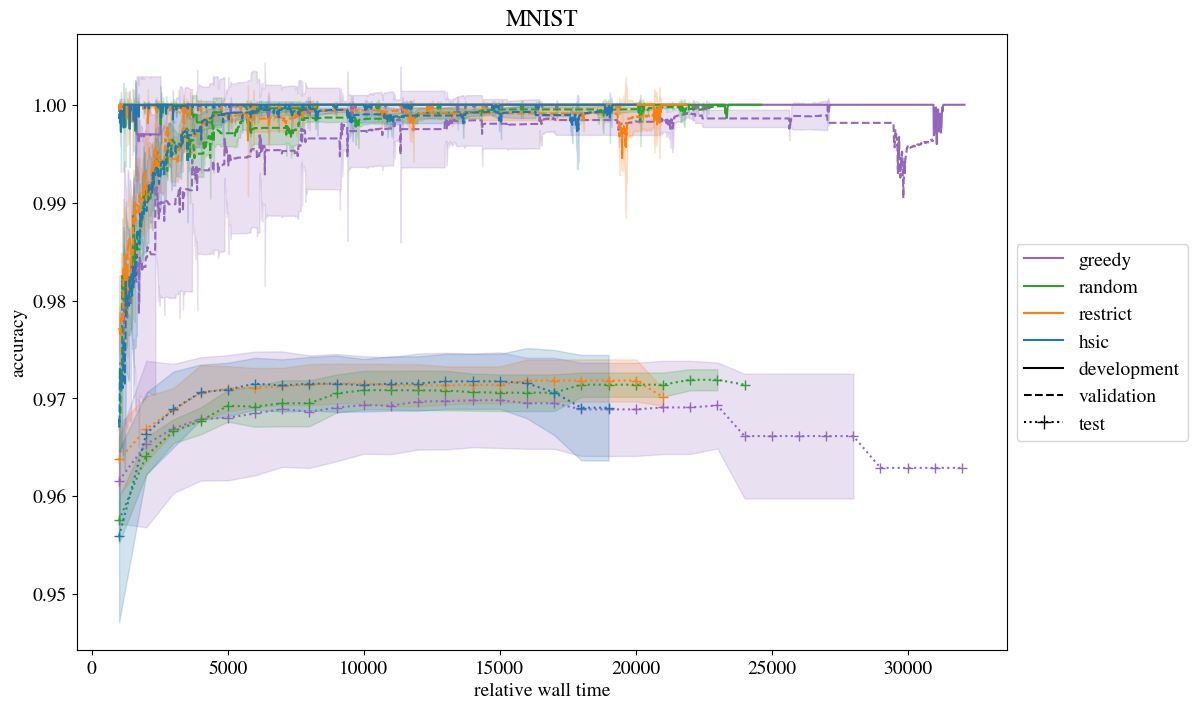

In [349]:
step = 10
crop = 100
crop_end = 10_500
fig, ax1 = plt.subplots(figsize=(12,8))

time_dev, time_val, time_test = {}, {}, {}
for name in run_info_t.keys():
    _name = name[:-2]
    if _name not in time_dev:
        time_dev[_name] = []
        time_val[_name] = []
        time_test[_name] = []
    time_dev[_name].append(list(run_info_t[name]["Intermediate training/dev accuracy"].keys())[-1])  # truncate to shortest run

max_time = {_name: max(time_dev[_name]) for _name in time_dev.keys()}
time_grid = {_name: np.arange(0, max_time[_name], step=step) for _name in time_dev.keys()}
time_grid_test = {_name: np.arange(0, max_time[_name], step=1_000) for _name in time_dev.keys()}

interp_dev, interp_val, interp_test = {}, {}, {}

for name in run_info_t.keys():
    _name = name[:-2]
    if _name not in interp_dev: 
        interp_dev[_name] = []
        interp_val[_name] = []
        interp_test[_name] = []
    
    f = interp1d(
        list(run_info_t[name]["Intermediate training/dev accuracy"].keys()),
        list(run_info_t[name]["Intermediate training/dev accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_dev[_name].append(f(time_grid[_name]))  # shape: (n_experiments, n_time_points)
    
    f = interp1d(
        list(run_info_t[name]["Intermediate training/val accuracy"].keys()),
        list(run_info_t[name]["Intermediate training/val accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_val[_name].append(f(time_grid[_name]))  # shape: (n_experiments, n_time_points)
    
    f = interp1d(
        list(run_info_t[name]["test accuracy"].keys()),
        list(run_info_t[name]["test accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_test[_name].append(f(time_grid_test[_name]))  # shape: (n_experiments, n_time_points)


for _name in interp_dev.keys():
    dev_mean = np.nanmean(interp_dev[_name], axis=0)
    sem = stats.sem(interp_dev[_name], axis=0, nan_policy="omit")
    dev_conf = 1.96 * sem

    ax1.plot(
        time_grid[_name][crop:],
        dev_mean[crop:],
        color=colors[_name],
        label=_name,
        linestyle="-",
    )
    ax1.fill_between(
        time_grid[_name][crop:],
        dev_mean[crop:] - dev_conf[crop:],
        dev_mean[crop:] + dev_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )

    val_mean = np.nanmean(interp_val[_name], axis=0)
    sem = stats.sem(interp_val[_name], axis=0, nan_policy="omit")
    val_conf = 1.96 * sem
    ax1.plot(
        time_grid[_name][crop:],
        val_mean[crop:],
        color=colors[_name],
        # label=_name,
        linestyle="--",
    )
    ax1.fill_between(
        time_grid[_name][crop:],
        val_mean[crop:] - val_conf[crop:],
        val_mean[crop:] + val_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )
    
    test_mean = np.nanmean(interp_test[_name], axis=0)
    sem = stats.sem(interp_test[_name], axis=0, nan_policy="omit")
    test_conf = 1.96 * sem
    ax1.plot(
        time_grid_test[_name][crop_start_acc:],
        test_mean[crop_start_acc:],
        color=colors[_name],
        # label=_name,
        markersize=7,
        linestyle=":",
        marker="+",
    )
    ax1.fill_between(
        time_grid_test[_name][crop_start_acc:],
        test_mean[crop_start_acc:] - test_conf[crop_start_acc:],
        test_mean[crop_start_acc:] + test_conf[crop_start_acc:],
        color=colors[_name],
        alpha=0.2,
    )



myHandle = [
    Line2D([], [], color="k", markersize=10, linestyle="-"),
    Line2D([], [], color="k", markersize=10, linestyle="--"),
    Line2D([], [], color="k", markersize=10, linestyle=":", marker="+"),
]

legend(ax1, extra_lines=myHandle, extra_labels=["development", "validation", "test"])
plt.xlabel("relative wall time")
plt.ylabel("accuracy")
plt.title("MNIST")
plt.show()

/tmp/ipykernel_4727/774447723.py:50: RuntimeWarning: Mean of empty slice
  dev_mean = np.nanmean(interp_dev[_name], axis=0)
/tmp/ipykernel_4727/774447723.py:69: RuntimeWarning: Mean of empty slice
  val_mean = np.nanmean(interp_val[_name], axis=0)
/tmp/ipykernel_4727/774447723.py:87: RuntimeWarning: Mean of empty slice
  test_mean = np.nanmean(interp_test[_name], axis=0)


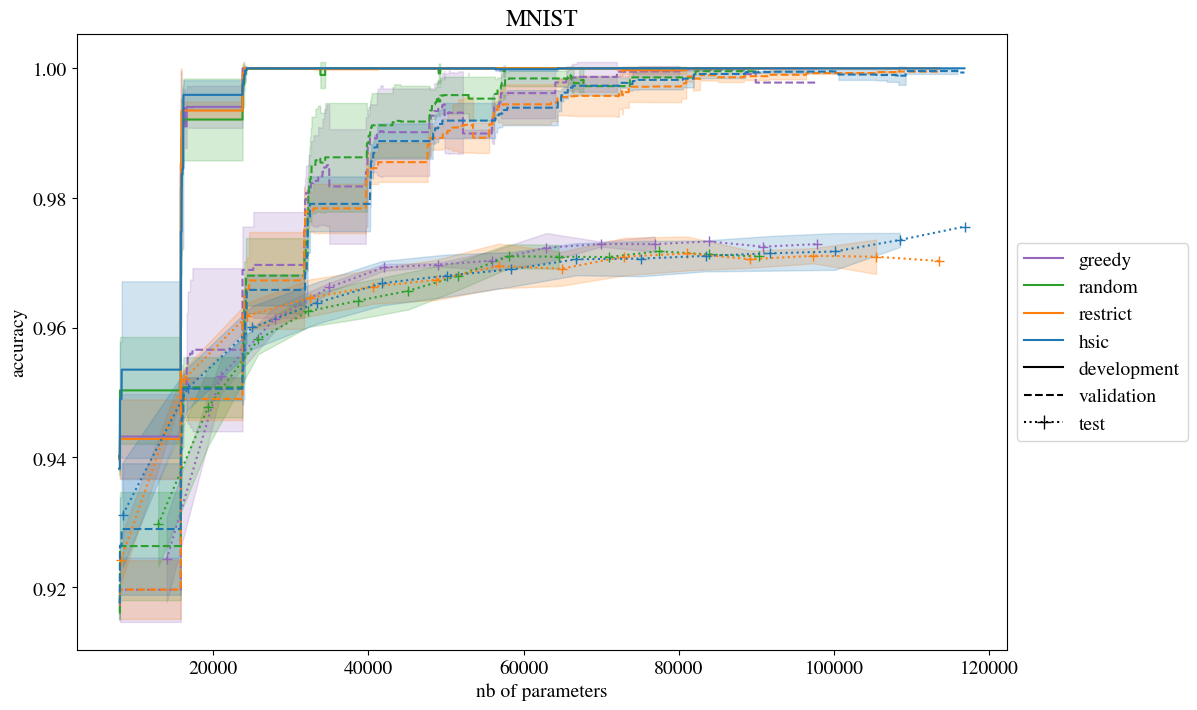

In [350]:
step = 10
crop = 0
crop_end = 10_000
fig, ax1 = plt.subplots(figsize=(12,8))

param_dev = {}
for name in run_info.keys():
    _name = name[:-2]
    if _name not in param_dev:
        param_dev[_name] = []
    param_dev[_name].append(list(run_info[name]["complexity/nb of parameters"].values())[-1])

max_params = {_name: max(param_dev[_name]) for _name in time_dev.keys()}
param_grid = {_name: np.arange(0, max_params[_name], step=step) for _name in param_dev.keys()}
param_grid_test = {_name: np.linspace(0, max_params[_name], num=15) for _name in time_dev.keys()}


interp_dev, interp_val, interp_test = {}, {}, {}

for name in run_info_t.keys():
    _name = name[:-2]
    if _name not in interp_dev: 
        interp_dev[_name] = []
        interp_val[_name] = []
        interp_test[_name] = []
        
    f = interp1d(
        list(run_info[name]["complexity/nb of parameters"].values()),
        list(run_info[name]["dev accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_dev[_name].append(f(param_grid[_name]))  # shape: (n_experiments, n_time_points)
    
    f = interp1d(
        list(run_info[name]["complexity/nb of parameters"].values()),
        list(run_info[name]["val accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_val[_name].append(f(param_grid[_name]))  # shape: (n_experiments, n_time_points)
    
    f = interp1d(
        list(run_info[name]["complexity/nb of parameters"].values()),
        list(run_info[name]["test accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_test[_name].append(f(param_grid_test[_name]))  # shape: (n_experiments, n_time_points)


for _name in interp_dev.keys():
    dev_mean = np.nanmean(interp_dev[_name], axis=0)
    sem = stats.sem(interp_dev[_name], axis=0, nan_policy="omit")
    dev_conf = 1.96 * sem

    ax1.plot(
        param_grid[_name][crop:],
        dev_mean[crop:],
        color=colors[_name],
        label=_name,
        linestyle="-",
    )
    ax1.fill_between(
        param_grid[_name][crop:],
        dev_mean[crop:] - dev_conf[crop:],
        dev_mean[crop:] + dev_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )

    val_mean = np.nanmean(interp_val[_name], axis=0)
    sem = stats.sem(interp_val[_name], axis=0, nan_policy="omit")
    val_conf = 1.96 * sem
    ax1.plot(
        param_grid[_name][crop:],
        val_mean[crop:],
        color=colors[_name],
        # label=_name,
        linestyle="--",
    )
    ax1.fill_between(
        param_grid[_name][crop:],
        val_mean[crop:] - val_conf[crop:],
        val_mean[crop:] + val_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )
    
    test_mean = np.nanmean(interp_test[_name], axis=0)
    sem = stats.sem(interp_test[_name], axis=0, nan_policy="omit")
    test_conf = 1.96 * sem
    ax1.plot(
        param_grid_test[_name][crop:],
        test_mean[crop:],
        color=colors[_name],
        # label=_name,
        markersize=7,
        linestyle=":",
        marker="+",
    )
    ax1.fill_between(
        param_grid_test[_name][crop:],
        test_mean[crop:] - test_conf[crop:],
        test_mean[crop:] + test_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )



myHandle = [
    Line2D([], [], color="k", markersize=10, linestyle="-"),
    Line2D([], [], color="k", markersize=10, linestyle="--"),
    Line2D([], [], color="k", markersize=10, linestyle=":", marker="+"),
]

legend(ax1, extra_lines=myHandle, extra_labels=["development", "validation", "test"])
plt.xlabel("nb of parameters")
plt.ylabel("accuracy")
plt.title("MNIST")
plt.show()

# AddNIST

## Get experiments

In [16]:
runIds_add = get_runs("HSIC-AddNIST")
runIds_add

Number of runs 16


{'hsic_4': '163f53056f134494a07302a03c169b73',
 'hsic_2': 'db9af26e167a49f585ed75aad27de098',
 'hsic_3': '2223a2c83b314b218a331e7455feaca8',
 'hsic_1': 'd49941d3c5fd4780a7e5fa2f641d89c5',
 'random_4': 'aeb6a51c6f46498fa22b9871fef56482',
 'random_3': '2b5055b6612c40479861d4db66218d3a',
 'random_1': 'b940fb243284441083bc37de2d77d122',
 'random_2': '3e17d8981f94429fa6599b64e42f0d09',
 'restrict_4': '6fcea757a9b443aaa48578264ad961bb',
 'restrict_3': 'c10f533419b34c7fa59015ef6c74bc0a',
 'restrict_2': 'e108e7504102422d935232f84255fc9e',
 'restrict_1': '7edf8718149046d3834839205a899ba1',
 'greedy_2': '1642780631864053a9676177ccf52326',
 'greedy_1': '2b42dcf9c26a430792f9637d3878f744',
 'greedy_3': 'e2ae07ca4c084e27a1f34c7f83758e81',
 'greedy_4': 'e21aae81ce4948c4a75d861e594fd200'}

In [17]:
run_info_add, run_info_add_t = get_logs(list(runIds_add.values()))
list(run_info_add.keys())

['163f53056f134494a07302a03c169b73', 'db9af26e167a49f585ed75aad27de098', '2223a2c83b314b218a331e7455feaca8', 'd49941d3c5fd4780a7e5fa2f641d89c5', 'aeb6a51c6f46498fa22b9871fef56482', '2b5055b6612c40479861d4db66218d3a', 'b940fb243284441083bc37de2d77d122', '3e17d8981f94429fa6599b64e42f0d09', '6fcea757a9b443aaa48578264ad961bb', 'c10f533419b34c7fa59015ef6c74bc0a', 'e108e7504102422d935232f84255fc9e', '7edf8718149046d3834839205a899ba1', '1642780631864053a9676177ccf52326', '2b42dcf9c26a430792f9637d3878f744', 'e2ae07ca4c084e27a1f34c7f83758e81', 'e21aae81ce4948c4a75d861e594fd200']


  5%|▌         | 12/231 [00:00<00:04, 53.31it/s]

100%|██████████| 346/346 [00:01<00:00, 242.83it/s]


['hsic_4',
 'hsic_2',
 'hsic_3',
 'hsic_1',
 'random_4',
 'random_3',
 'random_1',
 'random_2',
 'restrict_4',
 'restrict_3',
 'restrict_2',
 'restrict_1',
 'greedy_2',
 'greedy_1',
 'greedy_3',
 'greedy_4']

## Plots

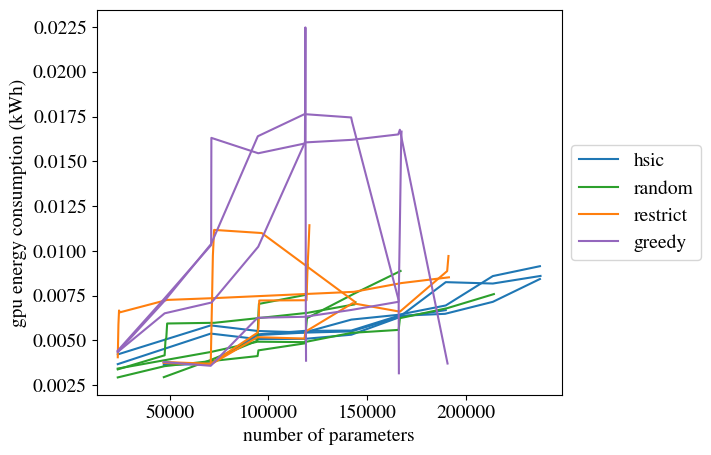

In [18]:
fig, ax1 = plt.subplots(figsize=(6, 5))
for name in run_info_add.keys():
    min_value = min(len(run_info_add[name]["complexity/nb of parameters"].values()), len(run_info_add[name]["codecarbon/gpu_energy"].values()))
    ax1.plot(
        list(run_info_add[name]["complexity/nb of parameters"].values())[:min_value],
        list(run_info_add[name]["codecarbon/gpu_energy"].values())[:min_value],
        label=f"{name}",
        color=colors[name[:-2]]
    )
    # ax1.plot(run_info["complexity/nb of parameters"][i].values(), list(accumulate(run_info["codecarbon/gpu_energy"][i].values())), "-", c=colors[1], label=f"cumulative")
legend(ax1, trim_labels=2)
ax1.set_xlabel("number of parameters")
ax1.set_ylabel("gpu energy consumption (kWh)")
# ax1.set_xscale("log")
plt.show()

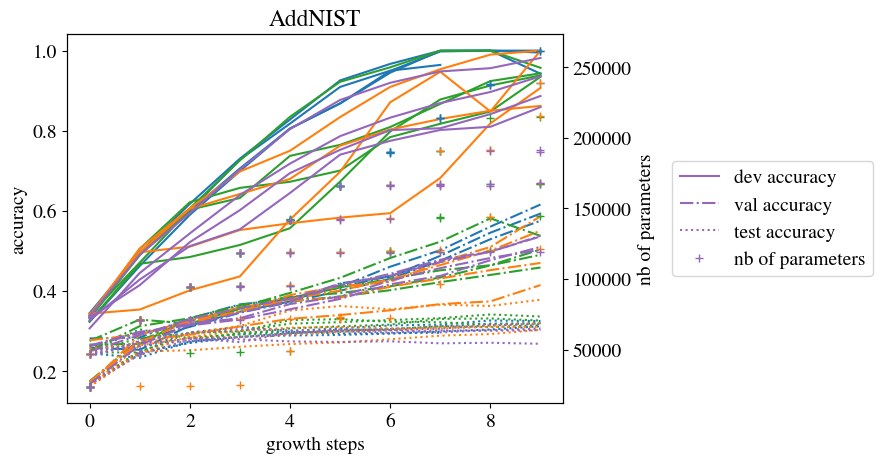

In [19]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
for name in run_info_add.keys():
    ax1.plot(
        run_info_add[name]["dev accuracy"].values(), "-", color=colors[name[:-2]], label="dev accuracy"
    )
    ax1.plot(
        run_info_add[name]["val accuracy"].values(),
        "-.",
        color=colors[name[:-2]],
        label="val accuracy",
    )
    ax1.plot(
        run_info_add[name]["test accuracy"].values(),
        ":",
        color=colors[name[:-2]],
        label="test accuracy",
    )
    ax2.plot(
        run_info_add[name]["complexity/nb of parameters"].values(),
        "+",
        color=colors[name[:-2]],
        label="nb of parameters",
    )
ax1.set_ylabel("accuracy")
ax2.set_ylabel("nb of parameters")
ax1.set_xlabel("growth steps")
plt.xlabel("steps")
plt.title("AddNIST")
legend(ax1, ax2, bbox_to_anchor=(1.2, 0.5))
plt.show()

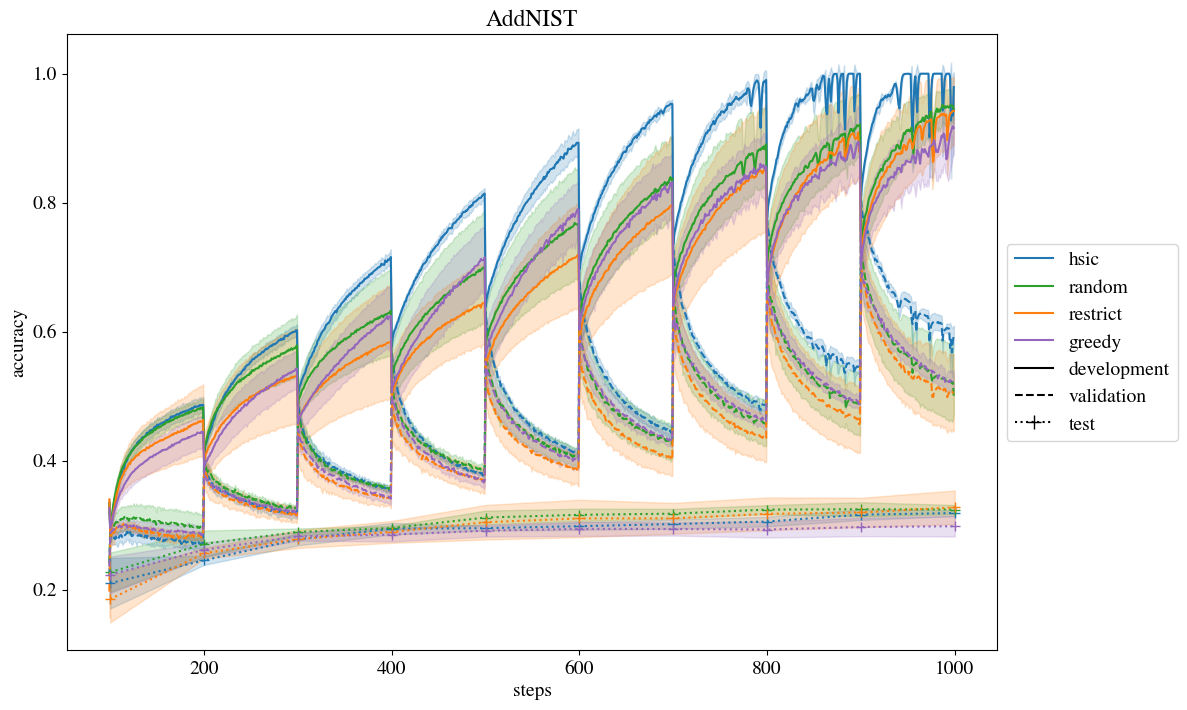

In [20]:
crop = 99
crop_end = 1_500
epoch_len = 100
epochs = 10
fig, ax1 = plt.subplots(figsize=(12,8))

dev_, val_, test_ = {}, {}, {}
for name in run_info_add.keys():
    _name = name[:-2]
    if _name not in dev_:
        dev_[_name] = []
        val_[_name] = []
        test_[_name] = []
    
    run_dev = list(run_info_add[name]["Intermediate training/dev accuracy"].values())
    run_val = list(run_info_add[name]["Intermediate training/val accuracy"].values())
    run_test = list(run_info_add[name]["test accuracy"].values())
    if len(run_dev) < epoch_len*epochs:
        run_dev = np.pad(run_dev, (0, epoch_len*epochs - len(run_dev)), constant_values=np.nan)
        run_val = np.pad(run_val, (0, epoch_len*epochs - len(run_val)), constant_values=np.nan)
        run_test = np.pad(run_test, (0, epochs - len(run_test)), constant_values=np.nan)
    dev_[_name].append(run_dev)
    val_[_name].append(run_val)
    test_[_name].append(run_test)

indx = list(run_info_add[name]["Intermediate training/dev accuracy"].keys())
indx_test = list(run_info_add[name]["test accuracy"].keys())
epoch_len = indx_test[0]
crop_start_acc, crop_end_acc = int(crop / epoch_len), int(crop_end / epoch_len)

dev_mean, dev_std, dev_conf = {}, {}, {}
val_mean, val_std, val_conf = {}, {}, {}
test_mean, test_std, test_conf = {}, {}, {}
for _name in dev_.keys():
    dev_mean[_name] = np.nanmean(dev_[_name], axis=0)
    dev_std[_name] = np.nanstd(dev_[_name], axis=0)
    dev_conf[_name] = 1.96 * dev_std[_name] / np.sqrt(5)
    val_mean[_name] = np.nanmean(val_[_name], axis=0)
    val_std[_name] = np.nanstd(val_[_name], axis=0)
    val_conf[_name] = 1.96 * val_std[_name] / np.sqrt(5)
    test_mean[_name] = np.nanmean(test_[_name], axis=0)
    test_std[_name] = np.nanstd(test_[_name], axis=0)
    test_conf[_name] = 1.96 * test_std[_name] / np.sqrt(5)

    ax1.plot(
        indx[crop:crop_end],
        dev_mean[_name][crop:crop_end],
        color=colors[_name],
        label=_name,
        linestyle="-",
    )
    ax1.fill_between(
        indx[crop:crop_end],
        dev_mean[_name][crop:crop_end] - dev_conf[_name][crop:crop_end],
        dev_mean[_name][crop:crop_end] + dev_conf[_name][crop:crop_end],
        color=colors[_name],
        alpha=0.2,
    )

    ax1.plot(
        indx[crop:crop_end],
        val_mean[_name][crop:crop_end],
        color=colors[_name],
        # label=_name,
        linestyle="--",
    )
    ax1.fill_between(
        indx[crop:crop_end],
        # val_mean[_name][crop:crop_end] - val_std[_name][crop:crop_end],
        # val_mean[_name][crop:crop_end] + val_std[_name][crop:crop_end],
        val_mean[_name][crop:crop_end] - val_conf[_name][crop:crop_end],
        val_mean[_name][crop:crop_end] + val_conf[_name][crop:crop_end],
        color=colors[_name],
        alpha=0.2,
    )
    
    ax1.plot(
        indx_test[crop_start_acc:crop_end_acc],
        test_mean[_name][crop_start_acc:crop_end_acc],
        color=colors[_name],
        # label=_name,
        markersize=7,
        linestyle=":",
        marker="+",
    )
    ax1.fill_between(
        indx_test[crop_start_acc:crop_end_acc],
        test_mean[_name][crop_start_acc:crop_end_acc] - test_conf[_name][crop_start_acc:crop_end_acc],
        test_mean[_name][crop_start_acc:crop_end_acc] + test_conf[_name][crop_start_acc:crop_end_acc],
        color=colors[_name],
        alpha=0.2,
    )



myHandle = [
    Line2D([], [], color="k", markersize=10, linestyle="-"),
    Line2D([], [], color="k", markersize=10, linestyle="--"),
    Line2D([], [], color="k", markersize=10, linestyle=":", marker="+"),
]

legend(ax1, extra_lines=myHandle, extra_labels=["development", "validation", "test"])
plt.xlabel("steps")
plt.ylabel("accuracy")
plt.title("AddNIST")
plt.show()

/tmp/ipykernel_31550/504626821.py:51: RuntimeWarning: Mean of empty slice
  dev_mean = np.nanmean(interp_dev[_name], axis=0)
/tmp/ipykernel_31550/504626821.py:70: RuntimeWarning: Mean of empty slice
  val_mean = np.nanmean(interp_val[_name], axis=0)
/tmp/ipykernel_31550/504626821.py:88: RuntimeWarning: Mean of empty slice
  test_mean = np.nanmean(interp_test[_name], axis=0)


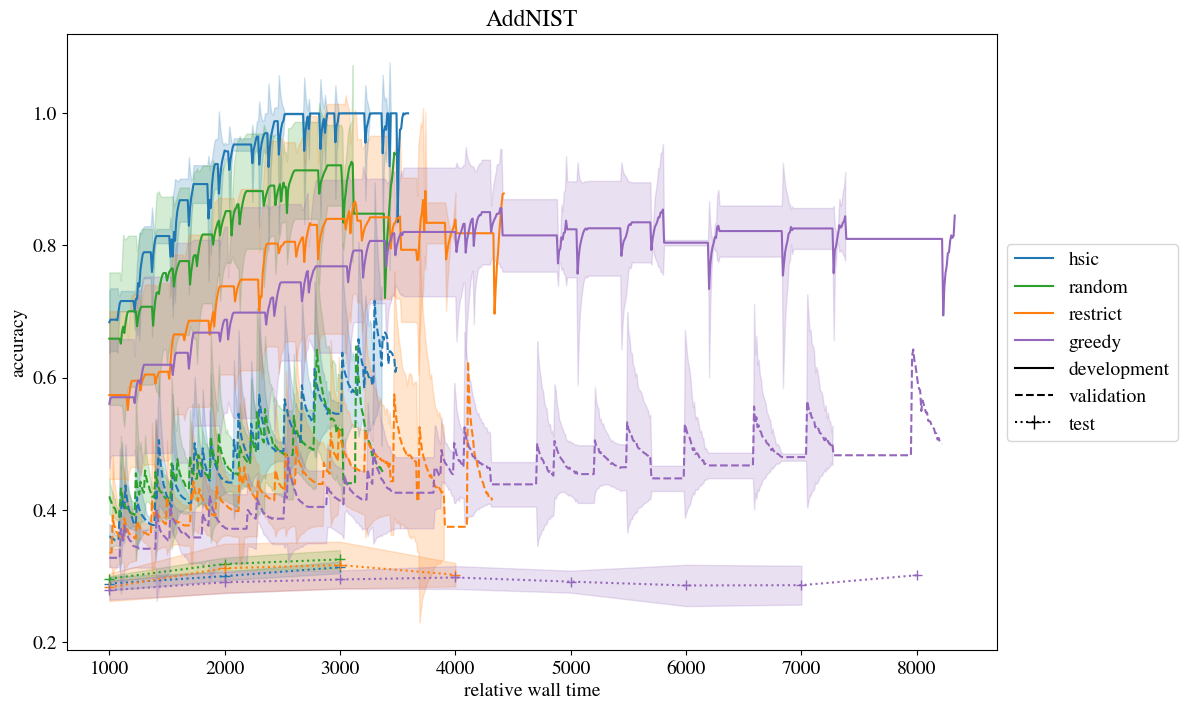

In [21]:
step = 10
crop = 100
crop_end = 10_500
fig, ax1 = plt.subplots(figsize=(12,8))

time_dev, time_val, time_test = {}, {}, {}
for name in run_info_add_t.keys():
    _name = name[:-2]
    if _name not in time_dev:
        time_dev[_name] = []
        time_val[_name] = []
        time_test[_name] = []
    time_dev[_name].append(list(run_info_add_t[name]["Intermediate training/dev accuracy"].keys())[-1])  # truncate to shortest run

max_time = {_name: max(time_dev[_name]) for _name in time_dev.keys()}
time_grid = {_name: np.arange(0, max_time[_name], step=step) for _name in time_dev.keys()}
time_grid_test = {_name: np.arange(0, max_time[_name], step=1_000) for _name in time_dev.keys()}

interp_dev, interp_val, interp_test = {}, {}, {}

for name in run_info_add_t.keys():
    _name = name[:-2]
    if _name not in interp_dev: 
        interp_dev[_name] = []
        interp_val[_name] = []
        interp_test[_name] = []
    
    f = interp1d(
        list(run_info_add_t[name]["Intermediate training/dev accuracy"].keys()),
        list(run_info_add_t[name]["Intermediate training/dev accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_dev[_name].append(f(time_grid[_name]))  # shape: (n_experiments, n_time_points)
    
    f = interp1d(
        list(run_info_add_t[name]["Intermediate training/val accuracy"].keys()),
        list(run_info_add_t[name]["Intermediate training/val accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_val[_name].append(f(time_grid[_name]))  # shape: (n_experiments, n_time_points)
    
    f = interp1d(
        list(run_info_add_t[name]["test accuracy"].keys()),
        list(run_info_add_t[name]["test accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_test[_name].append(f(time_grid_test[_name]))  # shape: (n_experiments, n_time_points)


for _name in interp_dev.keys():
    dev_mean = np.nanmean(interp_dev[_name], axis=0)
    sem = stats.sem(interp_dev[_name], axis=0, nan_policy="omit")
    dev_conf = 1.96 * sem

    ax1.plot(
        time_grid[_name][crop:],
        dev_mean[crop:],
        color=colors[_name],
        label=_name,
        linestyle="-",
    )
    ax1.fill_between(
        time_grid[_name][crop:],
        dev_mean[crop:] - dev_conf[crop:],
        dev_mean[crop:] + dev_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )

    val_mean = np.nanmean(interp_val[_name], axis=0)
    sem = stats.sem(interp_val[_name], axis=0, nan_policy="omit")
    val_conf = 1.96 * sem
    ax1.plot(
        time_grid[_name][crop:],
        val_mean[crop:],
        color=colors[_name],
        # label=_name,
        linestyle="--",
    )
    ax1.fill_between(
        time_grid[_name][crop:],
        val_mean[crop:] - val_conf[crop:],
        val_mean[crop:] + val_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )
    
    test_mean = np.nanmean(interp_test[_name], axis=0)
    sem = stats.sem(interp_test[_name], axis=0, nan_policy="omit")
    test_conf = 1.96 * sem
    ax1.plot(
        time_grid_test[_name][crop_start_acc:],
        test_mean[crop_start_acc:],
        color=colors[_name],
        # label=_name,
        markersize=7,
        linestyle=":",
        marker="+",
    )
    ax1.fill_between(
        time_grid_test[_name][crop_start_acc:],
        test_mean[crop_start_acc:] - test_conf[crop_start_acc:],
        test_mean[crop_start_acc:] + test_conf[crop_start_acc:],
        color=colors[_name],
        alpha=0.2,
    )



myHandle = [
    Line2D([], [], color="k", markersize=10, linestyle="-"),
    Line2D([], [], color="k", markersize=10, linestyle="--"),
    Line2D([], [], color="k", markersize=10, linestyle=":", marker="+"),
]

legend(ax1, extra_lines=myHandle, extra_labels=["development", "validation", "test"])
plt.xlabel("relative wall time")
plt.ylabel("accuracy")
plt.title("AddNIST")
plt.show()

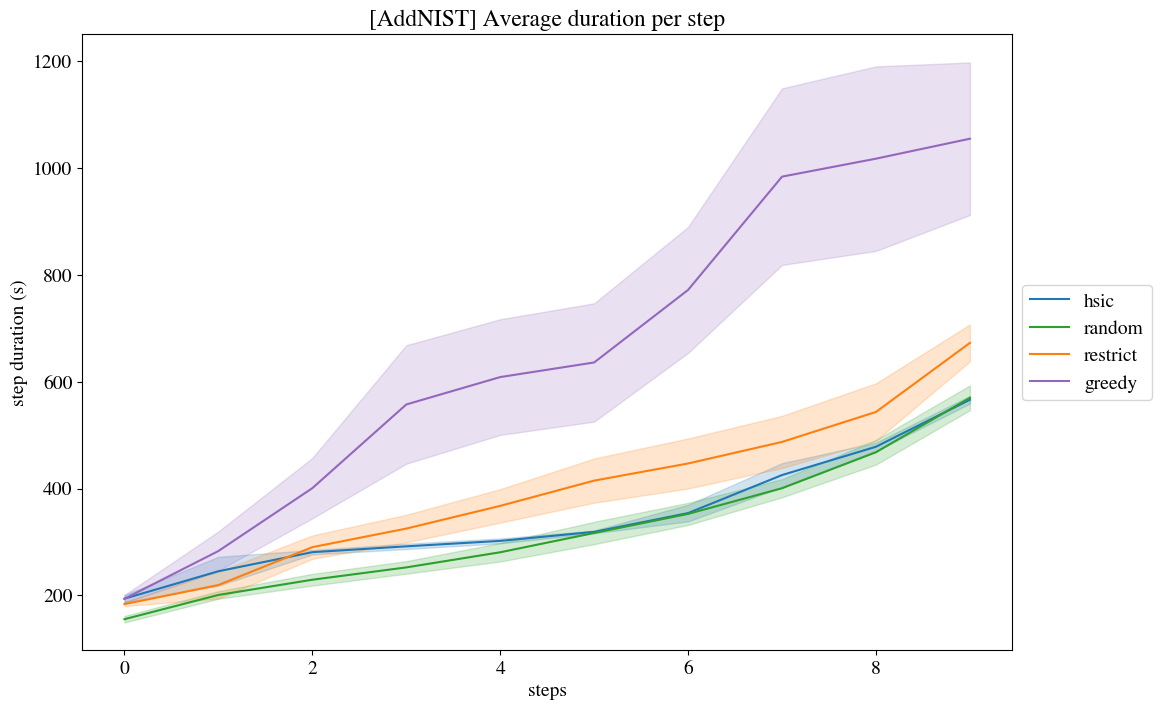

In [57]:
epochs = 10

dur_list = {}
for name in run_info_add_t.keys():
    _name = name[:-2]
    if _name not in dur_list: dur_list[_name] = []

    test_dur = [0]+list(run_info_add_t[name]["test accuracy"].keys())
    test_dur = [test_dur[step]-test_dur[step-1] for step in range(1, len(test_dur))]

    if len(test_dur) < epochs:
        test_dur = np.pad(test_dur, (0, epochs - len(test_dur)), constant_values=np.nan)

    dur_list[_name].append(test_dur)


fig, ax1 = plt.subplots(figsize=(12,8))

dur_mean, dur_std, dur_conf = {}, {}, {}
indx = np.arange(0, epochs)
# indx_test = list(run_info_add[name]["test accuracy"].keys())
for _name in dur_list.keys():
    dur_mean[_name] = np.nanmean(dur_list[_name], axis=0)
    dur_std[_name] = np.nanstd(dur_list[_name], axis=0)
    dur_conf[_name] = 1.96 * dur_std[_name]/ np.sqrt(len(dur_mean[_name]))

    ax1.plot(
        indx,
        dur_mean[_name],
        color=colors[_name],
        label=_name,
        linestyle="-",
    )
    ax1.fill_between(
        indx,
        dur_mean[_name] - dur_conf[_name],
        dur_mean[_name] + dur_conf[_name],
        color=colors[_name],
        alpha=0.2,
    )
plt.title("[AddNIST] Average duration per step")
plt.xlabel("steps")
plt.ylabel("step duration (s)")
legend(ax1)
plt.show()

/tmp/ipykernel_31550/3877554213.py:50: RuntimeWarning: Mean of empty slice
  dev_mean = np.nanmean(interp_dev[_name], axis=0)
/tmp/ipykernel_31550/3877554213.py:69: RuntimeWarning: Mean of empty slice
  val_mean = np.nanmean(interp_val[_name], axis=0)
/tmp/ipykernel_31550/3877554213.py:87: RuntimeWarning: Mean of empty slice
  test_mean = np.nanmean(interp_test[_name], axis=0)


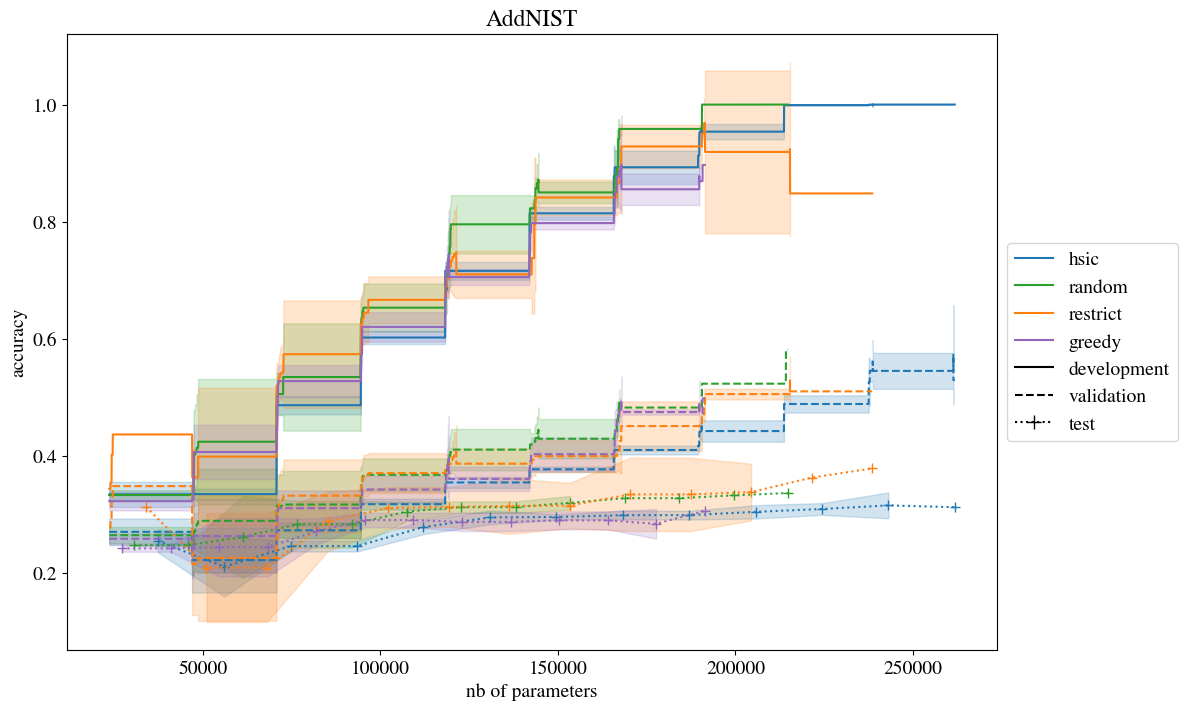

In [22]:
step = 10
crop = 0
crop_end = 10_000
fig, ax1 = plt.subplots(figsize=(12,8))

param_dev = {}
for name in run_info_add.keys():
    _name = name[:-2]
    if _name not in param_dev:
        param_dev[_name] = []
    param_dev[_name].append(list(run_info_add[name]["complexity/nb of parameters"].values())[-1])

max_params = {_name: max(param_dev[_name]) for _name in time_dev.keys()}
param_grid = {_name: np.arange(0, max_params[_name], step=step) for _name in param_dev.keys()}
param_grid_test = {_name: np.linspace(0, max_params[_name], num=15) for _name in time_dev.keys()}


interp_dev, interp_val, interp_test = {}, {}, {}

for name in run_info_add.keys():
    _name = name[:-2]
    if _name not in interp_dev: 
        interp_dev[_name] = []
        interp_val[_name] = []
        interp_test[_name] = []
        
    f = interp1d(
        list(run_info_add[name]["complexity/nb of parameters"].values()),
        list(run_info_add[name]["dev accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_dev[_name].append(f(param_grid[_name]))  # shape: (n_experiments, n_time_points)
    
    f = interp1d(
        list(run_info_add[name]["complexity/nb of parameters"].values()),
        list(run_info_add[name]["val accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_val[_name].append(f(param_grid[_name]))  # shape: (n_experiments, n_time_points)
    
    f = interp1d(
        list(run_info_add[name]["complexity/nb of parameters"].values()),
        list(run_info_add[name]["test accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_test[_name].append(f(param_grid_test[_name]))  # shape: (n_experiments, n_time_points)


for _name in interp_dev.keys():
    dev_mean = np.nanmean(interp_dev[_name], axis=0)
    sem = stats.sem(interp_dev[_name], axis=0, nan_policy="omit")
    dev_conf = 1.96 * sem

    ax1.plot(
        param_grid[_name][crop:],
        dev_mean[crop:],
        color=colors[_name],
        label=_name,
        linestyle="-",
    )
    ax1.fill_between(
        param_grid[_name][crop:],
        dev_mean[crop:] - dev_conf[crop:],
        dev_mean[crop:] + dev_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )

    val_mean = np.nanmean(interp_val[_name], axis=0)
    sem = stats.sem(interp_val[_name], axis=0, nan_policy="omit")
    val_conf = 1.96 * sem
    ax1.plot(
        param_grid[_name][crop:],
        val_mean[crop:],
        color=colors[_name],
        # label=_name,
        linestyle="--",
    )
    ax1.fill_between(
        param_grid[_name][crop:],
        val_mean[crop:] - val_conf[crop:],
        val_mean[crop:] + val_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )
    
    test_mean = np.nanmean(interp_test[_name], axis=0)
    sem = stats.sem(interp_test[_name], axis=0, nan_policy="omit")
    test_conf = 1.96 * sem
    ax1.plot(
        param_grid_test[_name][crop:],
        test_mean[crop:],
        color=colors[_name],
        # label=_name,
        markersize=7,
        linestyle=":",
        marker="+",
    )
    ax1.fill_between(
        param_grid_test[_name][crop:],
        test_mean[crop:] - test_conf[crop:],
        test_mean[crop:] + test_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )



myHandle = [
    Line2D([], [], color="k", markersize=10, linestyle="-"),
    Line2D([], [], color="k", markersize=10, linestyle="--"),
    Line2D([], [], color="k", markersize=10, linestyle=":", marker="+"),
]

legend(ax1, extra_lines=myHandle, extra_labels=["development", "validation", "test"])
plt.xlabel("nb of parameters")
plt.ylabel("accuracy")
plt.title("AddNIST")
plt.show()

# AddNISTv2

In [33]:
runIds_add = get_runs("HSIC-AddNISTv2")
runIds_add

Number of runs 17


{'crawling-crane-225': '2990193dd886417e86137844869ed48c',
 'random_1': '96b853df5b854a76b2d77fbf996ee0f6',
 'random_2': '362d37adbeba4cf0adf55f266a15e961',
 'random_3': '1866f1dd22fd425689b0e2482e9d3847',
 'random_4': 'b1e9fe2c2d74492b97eed1f558069c21',
 'restrict_1': 'c263be352862445994b06d7fccfc64dc',
 'restrict_4': 'cad6470d9d90472bb81702399d5ce4bd',
 'restrict_3': 'c673ccc06a2d485aaf66cd2ab934688b',
 'restrict_2': '07e32e25cb564219b4670bfea71a32d8',
 'greedy_3': '68a2a569aba14107873a4563205293ac',
 'greedy_4': '347aef3f9a164a34a26009ba0f16a140',
 'greedy_1': '2e4404eebabc46979ede617e06cdf48d',
 'greedy_2': '86ae8666068e463ea85a6bc735382e2a',
 'hsic_4': '7e0d67f4fe004eeb86f057d3bd693b8d',
 'hsic_3': '16cc025588bb473f9ffb3b106f5d80e9',
 'hsic_2': 'a993e5a27b2043f2ba22b903821df2ae',
 'hsic_1': 'b546e2c68a474060aacc32bfcf863b9e'}

In [34]:
run_info_add, run_info_add_t = get_logs(list(runIds_add.values()))
list(run_info_add.keys())

['2990193dd886417e86137844869ed48c', '96b853df5b854a76b2d77fbf996ee0f6', '362d37adbeba4cf0adf55f266a15e961', '1866f1dd22fd425689b0e2482e9d3847', 'b1e9fe2c2d74492b97eed1f558069c21', 'c263be352862445994b06d7fccfc64dc', 'cad6470d9d90472bb81702399d5ce4bd', 'c673ccc06a2d485aaf66cd2ab934688b', '07e32e25cb564219b4670bfea71a32d8', '68a2a569aba14107873a4563205293ac', '347aef3f9a164a34a26009ba0f16a140', '2e4404eebabc46979ede617e06cdf48d', '86ae8666068e463ea85a6bc735382e2a', '7e0d67f4fe004eeb86f057d3bd693b8d', '16cc025588bb473f9ffb3b106f5d80e9', 'a993e5a27b2043f2ba22b903821df2ae', 'b546e2c68a474060aacc32bfcf863b9e']


100%|██████████| 465/465 [00:03<00:00, 138.80it/s]


Could not get duration of run


100%|██████████| 287/287 [00:02<00:00, 97.49it/s] 


['crawling-crane-225',
 'random_1',
 'random_2',
 'random_3',
 'random_4',
 'restrict_1',
 'restrict_4',
 'restrict_3',
 'restrict_2',
 'greedy_3',
 'greedy_4',
 'greedy_1',
 'greedy_2',
 'hsic_4',
 'hsic_3',
 'hsic_2',
 'hsic_1']

## Plots

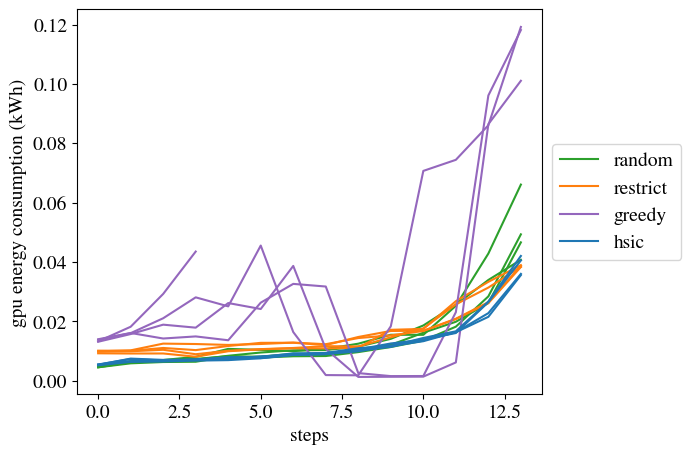

In [50]:
fig, ax1 = plt.subplots(figsize=(6, 5))
for name in run_info_add.keys():
    if name == 'crawling-crane-225': continue
    min_value = min(len(run_info_add[name]["complexity/nb of parameters"].values()), len(run_info_add[name]["codecarbon/gpu_energy"].values()))
    ax1.plot(
        # list(run_info_add[name]["complexity/nb of parameters"].values())[:min_value],
        list(run_info_add[name]["codecarbon/gpu_energy"].values())[:min_value],
        label=f"{name}",
        color=colors[name[:-2]]
    )
    # ax1.plot(run_info["complexity/nb of parameters"][i].values(), list(accumulate(run_info["codecarbon/gpu_energy"][i].values())), "-", c=colors[1], label=f"cumulative")
legend(ax1, trim_labels=2)
# ax1.set_xlabel("number of parameters")
ax1.set_xlabel("steps")
ax1.set_ylabel("gpu energy consumption (kWh)")
# ax1.set_xscale("log")
plt.show()

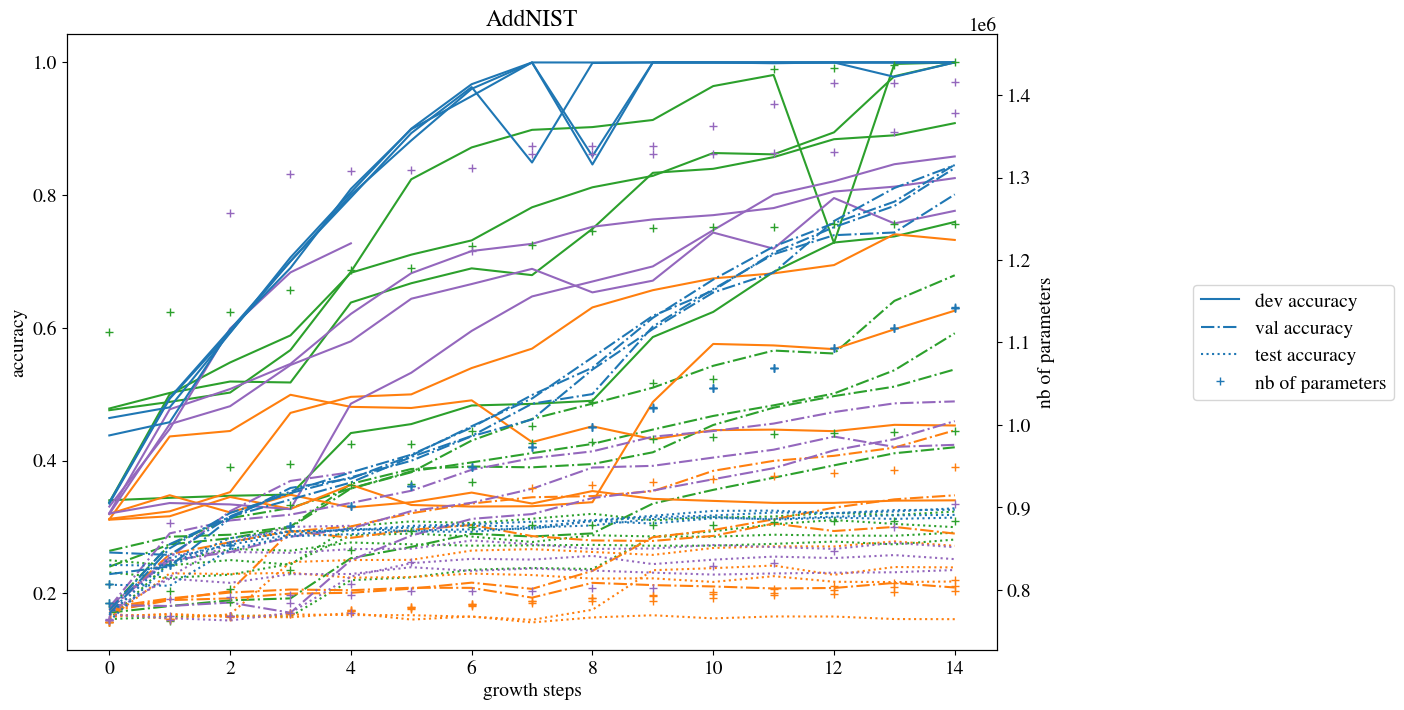

In [52]:
fig, ax1 = plt.subplots(figsize=(12,8))
ax2 = ax1.twinx()
for name in run_info_add.keys():
    if name == 'crawling-crane-225': continue
    ax1.plot(
        run_info_add[name]["dev accuracy"].values(), "-", color=colors[name[:-2]], label="dev accuracy"
    )
    ax1.plot(
        run_info_add[name]["val accuracy"].values(),
        "-.",
        color=colors[name[:-2]],
        label="val accuracy",
    )
    ax1.plot(
        run_info_add[name]["test accuracy"].values(),
        ":",
        color=colors[name[:-2]],
        label="test accuracy",
    )
    ax2.plot(
        run_info_add[name]["complexity/nb of parameters"].values(),
        "+",
        color=colors[name[:-2]],
        label="nb of parameters",
    )
ax1.set_ylabel("accuracy")
ax2.set_ylabel("nb of parameters")
ax1.set_xlabel("growth steps")
plt.xlabel("steps")
plt.title("AddNIST")
legend(ax1, ax2, bbox_to_anchor=(1.2, 0.5))
plt.show()

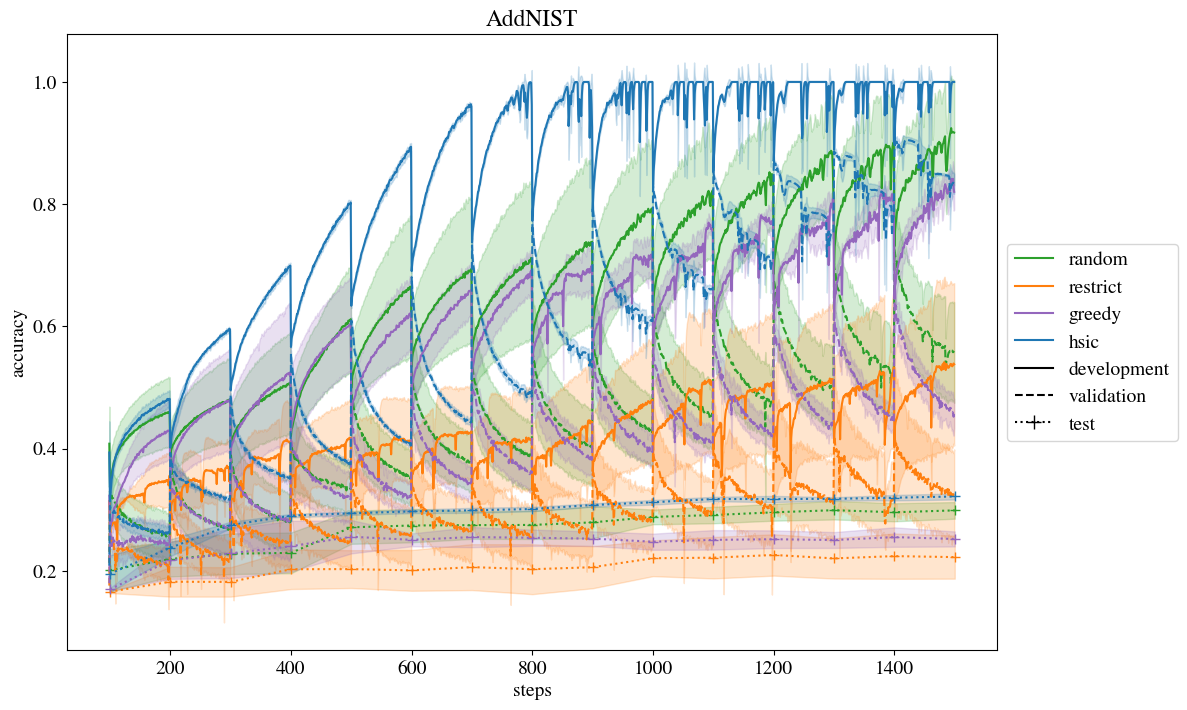

In [53]:
crop = 99
crop_end = 1_500
epoch_len = 100
epochs = 15
fig, ax1 = plt.subplots(figsize=(12,8))

dev_, val_, test_ = {}, {}, {}
for name in run_info_add.keys():
    if name == 'crawling-crane-225': continue
    _name = name[:-2]
    if _name not in dev_:
        dev_[_name] = []
        val_[_name] = []
        test_[_name] = []
    
    run_dev = list(run_info_add[name]["Intermediate training/dev accuracy"].values())
    run_val = list(run_info_add[name]["Intermediate training/val accuracy"].values())
    run_test = list(run_info_add[name]["test accuracy"].values())
    if len(run_dev) < epoch_len*epochs:
        run_dev = np.pad(run_dev, (0, epoch_len*epochs - len(run_dev)), constant_values=np.nan)
        run_val = np.pad(run_val, (0, epoch_len*epochs - len(run_val)), constant_values=np.nan)
        run_test = np.pad(run_test, (0, epochs - len(run_test)), constant_values=np.nan)
    dev_[_name].append(run_dev)
    val_[_name].append(run_val)
    test_[_name].append(run_test)

indx = list(run_info_add[name]["Intermediate training/dev accuracy"].keys())
indx_test = list(run_info_add[name]["test accuracy"].keys())
epoch_len = indx_test[0]
crop_start_acc, crop_end_acc = int(crop / epoch_len), int(crop_end / epoch_len)

dev_mean, dev_std, dev_conf = {}, {}, {}
val_mean, val_std, val_conf = {}, {}, {}
test_mean, test_std, test_conf = {}, {}, {}
for _name in dev_.keys():
    dev_mean[_name] = np.nanmean(dev_[_name], axis=0)
    dev_std[_name] = np.nanstd(dev_[_name], axis=0)
    dev_conf[_name] = 1.96 * dev_std[_name] / np.sqrt(5)
    val_mean[_name] = np.nanmean(val_[_name], axis=0)
    val_std[_name] = np.nanstd(val_[_name], axis=0)
    val_conf[_name] = 1.96 * val_std[_name] / np.sqrt(5)
    test_mean[_name] = np.nanmean(test_[_name], axis=0)
    test_std[_name] = np.nanstd(test_[_name], axis=0)
    test_conf[_name] = 1.96 * test_std[_name] / np.sqrt(5)

    ax1.plot(
        indx[crop:crop_end],
        dev_mean[_name][crop:crop_end],
        color=colors[_name],
        label=_name,
        linestyle="-",
    )
    ax1.fill_between(
        indx[crop:crop_end],
        dev_mean[_name][crop:crop_end] - dev_conf[_name][crop:crop_end],
        dev_mean[_name][crop:crop_end] + dev_conf[_name][crop:crop_end],
        color=colors[_name],
        alpha=0.2,
    )

    ax1.plot(
        indx[crop:crop_end],
        val_mean[_name][crop:crop_end],
        color=colors[_name],
        # label=_name,
        linestyle="--",
    )
    ax1.fill_between(
        indx[crop:crop_end],
        val_mean[_name][crop:crop_end] - val_conf[_name][crop:crop_end],
        val_mean[_name][crop:crop_end] + val_conf[_name][crop:crop_end],
        color=colors[_name],
        alpha=0.2,
    )
    
    ax1.plot(
        indx_test[crop_start_acc:crop_end_acc],
        test_mean[_name][crop_start_acc:crop_end_acc],
        color=colors[_name],
        # label=_name,
        markersize=7,
        linestyle=":",
        marker="+",
    )
    ax1.fill_between(
        indx_test[crop_start_acc:crop_end_acc],
        test_mean[_name][crop_start_acc:crop_end_acc] - test_conf[_name][crop_start_acc:crop_end_acc],
        test_mean[_name][crop_start_acc:crop_end_acc] + test_conf[_name][crop_start_acc:crop_end_acc],
        color=colors[_name],
        alpha=0.2,
    )



myHandle = [
    Line2D([], [], color="k", markersize=10, linestyle="-"),
    Line2D([], [], color="k", markersize=10, linestyle="--"),
    Line2D([], [], color="k", markersize=10, linestyle=":", marker="+"),
]

legend(ax1, extra_lines=myHandle, extra_labels=["development", "validation", "test"])
plt.xlabel("steps")
plt.ylabel("accuracy")
plt.title("AddNIST")
plt.show()

/tmp/ipykernel_27226/3797659776.py:53: RuntimeWarning: Mean of empty slice
  dev_mean = np.nanmean(interp_dev[_name], axis=0)
/tmp/ipykernel_27226/3797659776.py:72: RuntimeWarning: Mean of empty slice
  val_mean = np.nanmean(interp_val[_name], axis=0)
/tmp/ipykernel_27226/3797659776.py:90: RuntimeWarning: Mean of empty slice
  test_mean = np.nanmean(interp_test[_name], axis=0)


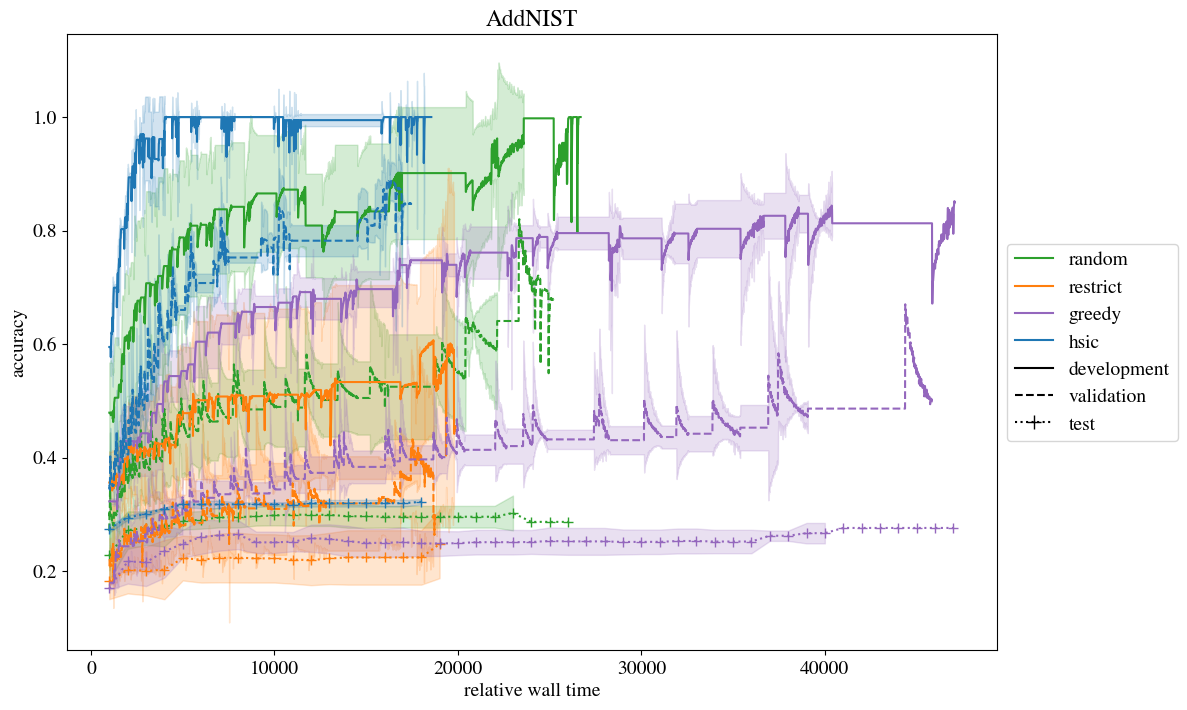

In [54]:
step = 10
crop = 100
crop_end = 10_500
fig, ax1 = plt.subplots(figsize=(12,8))

time_dev, time_val, time_test = {}, {}, {}
for name in run_info_add_t.keys():
    if name == 'crawling-crane-225': continue
    _name = name[:-2]
    if _name not in time_dev:
        time_dev[_name] = []
        time_val[_name] = []
        time_test[_name] = []
    time_dev[_name].append(list(run_info_add_t[name]["Intermediate training/dev accuracy"].keys())[-1])  # truncate to shortest run

max_time = {_name: max(time_dev[_name]) for _name in time_dev.keys()}
time_grid = {_name: np.arange(0, max_time[_name], step=step) for _name in time_dev.keys()}
time_grid_test = {_name: np.arange(0, max_time[_name], step=1_000) for _name in time_dev.keys()}

interp_dev, interp_val, interp_test = {}, {}, {}

for name in run_info_add_t.keys():
    if name == 'crawling-crane-225': continue
    _name = name[:-2]
    if _name not in interp_dev: 
        interp_dev[_name] = []
        interp_val[_name] = []
        interp_test[_name] = []
    
    f = interp1d(
        list(run_info_add_t[name]["Intermediate training/dev accuracy"].keys()),
        list(run_info_add_t[name]["Intermediate training/dev accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_dev[_name].append(f(time_grid[_name]))  # shape: (n_experiments, n_time_points)
    
    f = interp1d(
        list(run_info_add_t[name]["Intermediate training/val accuracy"].keys()),
        list(run_info_add_t[name]["Intermediate training/val accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_val[_name].append(f(time_grid[_name]))  # shape: (n_experiments, n_time_points)
    
    f = interp1d(
        list(run_info_add_t[name]["test accuracy"].keys()),
        list(run_info_add_t[name]["test accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_test[_name].append(f(time_grid_test[_name]))  # shape: (n_experiments, n_time_points)


for _name in interp_dev.keys():
    dev_mean = np.nanmean(interp_dev[_name], axis=0)
    sem = stats.sem(interp_dev[_name], axis=0, nan_policy="omit")
    dev_conf = 1.96 * sem

    ax1.plot(
        time_grid[_name][crop:],
        dev_mean[crop:],
        color=colors[_name],
        label=_name,
        linestyle="-",
    )
    ax1.fill_between(
        time_grid[_name][crop:],
        dev_mean[crop:] - dev_conf[crop:],
        dev_mean[crop:] + dev_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )

    val_mean = np.nanmean(interp_val[_name], axis=0)
    sem = stats.sem(interp_val[_name], axis=0, nan_policy="omit")
    val_conf = 1.96 * sem
    ax1.plot(
        time_grid[_name][crop:],
        val_mean[crop:],
        color=colors[_name],
        # label=_name,
        linestyle="--",
    )
    ax1.fill_between(
        time_grid[_name][crop:],
        val_mean[crop:] - val_conf[crop:],
        val_mean[crop:] + val_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )
    
    test_mean = np.nanmean(interp_test[_name], axis=0)
    sem = stats.sem(interp_test[_name], axis=0, nan_policy="omit")
    test_conf = 1.96 * sem
    ax1.plot(
        time_grid_test[_name][crop_start_acc:],
        test_mean[crop_start_acc:],
        color=colors[_name],
        # label=_name,
        markersize=7,
        linestyle=":",
        marker="+",
    )
    ax1.fill_between(
        time_grid_test[_name][crop_start_acc:],
        test_mean[crop_start_acc:] - test_conf[crop_start_acc:],
        test_mean[crop_start_acc:] + test_conf[crop_start_acc:],
        color=colors[_name],
        alpha=0.2,
    )



myHandle = [
    Line2D([], [], color="k", markersize=10, linestyle="-"),
    Line2D([], [], color="k", markersize=10, linestyle="--"),
    Line2D([], [], color="k", markersize=10, linestyle=":", marker="+"),
]

legend(ax1, extra_lines=myHandle, extra_labels=["development", "validation", "test"])
plt.xlabel("relative wall time")
plt.ylabel("accuracy")
plt.title("AddNIST")
plt.show()

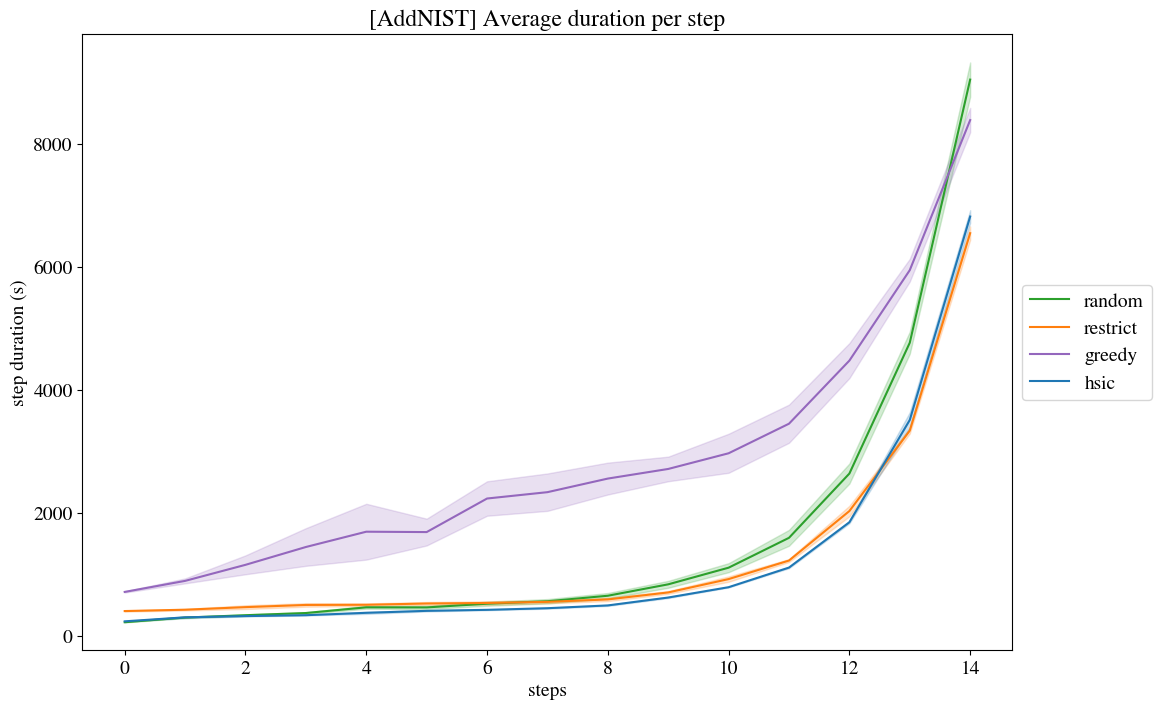

In [55]:
epochs = 15

dur_list = {}
for name in run_info_add_t.keys():
    if name == 'crawling-crane-225': continue
    _name = name[:-2]
    if _name not in dur_list: dur_list[_name] = []

    test_dur = [0]+list(run_info_add_t[name]["test accuracy"].keys())
    test_dur = [test_dur[step]-test_dur[step-1] for step in range(1, len(test_dur))]

    if len(test_dur) < epochs:
        test_dur = np.pad(test_dur, (0, epochs - len(test_dur)), constant_values=np.nan)

    dur_list[_name].append(test_dur)


fig, ax1 = plt.subplots(figsize=(12,8))

dur_mean, dur_std, dur_conf = {}, {}, {}
indx = np.arange(0, epochs)

for _name in dur_list.keys():
    dur_mean[_name] = np.nanmean(dur_list[_name], axis=0)
    dur_std[_name] = np.nanstd(dur_list[_name], axis=0)
    dur_conf[_name] = 1.96 * dur_std[_name]/ np.sqrt(len(dur_mean[_name]))

    ax1.plot(
        indx,
        dur_mean[_name],
        color=colors[_name],
        label=_name,
        linestyle="-",
    )
    ax1.fill_between(
        indx,
        dur_mean[_name] - dur_conf[_name],
        dur_mean[_name] + dur_conf[_name],
        color=colors[_name],
        alpha=0.2,
    )
plt.title("[AddNIST] Average duration per step")
plt.xlabel("steps")
plt.ylabel("step duration (s)")
legend(ax1)
plt.show()

/tmp/ipykernel_27226/1128779214.py:52: RuntimeWarning: Mean of empty slice
  dev_mean = np.nanmean(interp_dev[_name], axis=0)
/tmp/ipykernel_27226/1128779214.py:71: RuntimeWarning: Mean of empty slice
  val_mean = np.nanmean(interp_val[_name], axis=0)
/tmp/ipykernel_27226/1128779214.py:89: RuntimeWarning: Mean of empty slice
  test_mean = np.nanmean(interp_test[_name], axis=0)


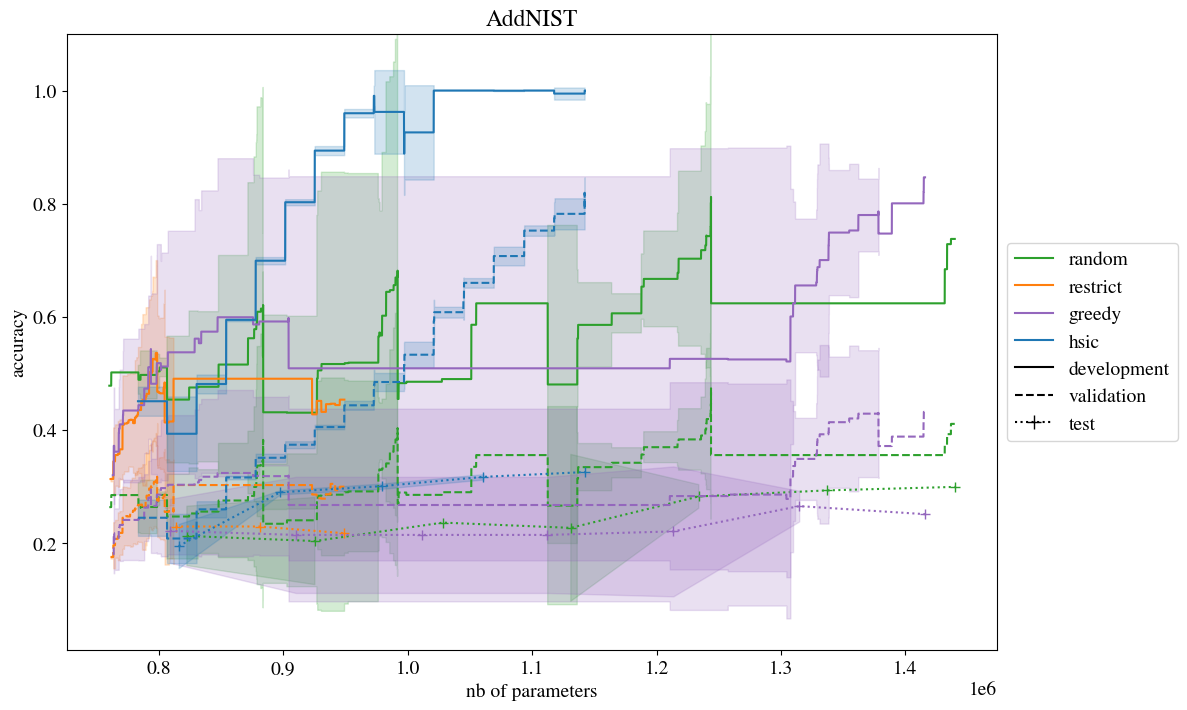

In [58]:
step = 10
crop = 0
crop_end = 10_000
fig, ax1 = plt.subplots(figsize=(12,8))

param_dev = {}
for name in run_info_add.keys():
    if name == 'crawling-crane-225': continue
    _name = name[:-2]
    if _name not in param_dev:
        param_dev[_name] = []
    param_dev[_name].append(list(run_info_add[name]["complexity/nb of parameters"].values())[-1])

max_params = {_name: max(param_dev[_name]) for _name in time_dev.keys()}
param_grid = {_name: np.arange(0, max_params[_name], step=step) for _name in param_dev.keys()}
param_grid_test = {_name: np.linspace(0, max_params[_name], num=15) for _name in time_dev.keys()}


interp_dev, interp_val, interp_test = {}, {}, {}

for name in run_info_add.keys():
    if name == 'crawling-crane-225': continue
    _name = name[:-2]
    if _name not in interp_dev: 
        interp_dev[_name] = []
        interp_val[_name] = []
        interp_test[_name] = []
        
    f = interp1d(
        list(run_info_add[name]["complexity/nb of parameters"].values()),
        list(run_info_add[name]["dev accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_dev[_name].append(f(param_grid[_name]))  # shape: (n_experiments, n_time_points)
    
    f = interp1d(
        list(run_info_add[name]["complexity/nb of parameters"].values()),
        list(run_info_add[name]["val accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_val[_name].append(f(param_grid[_name]))  # shape: (n_experiments, n_time_points)
    
    f = interp1d(
        list(run_info_add[name]["complexity/nb of parameters"].values()),
        list(run_info_add[name]["test accuracy"].values()),
        kind='previous', bounds_error=False, fill_value=np.nan
    )
    interp_test[_name].append(f(param_grid_test[_name]))  # shape: (n_experiments, n_time_points)


for _name in interp_dev.keys():
    dev_mean = np.nanmean(interp_dev[_name], axis=0)
    sem = stats.sem(interp_dev[_name], axis=0, nan_policy="omit")
    dev_conf = 1.96 * sem

    ax1.plot(
        param_grid[_name][crop:],
        dev_mean[crop:],
        color=colors[_name],
        label=_name,
        linestyle="-",
    )
    ax1.fill_between(
        param_grid[_name][crop:],
        dev_mean[crop:] - dev_conf[crop:],
        dev_mean[crop:] + dev_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )

    val_mean = np.nanmean(interp_val[_name], axis=0)
    sem = stats.sem(interp_val[_name], axis=0, nan_policy="omit")
    val_conf = 1.96 * sem
    ax1.plot(
        param_grid[_name][crop:],
        val_mean[crop:],
        color=colors[_name],
        # label=_name,
        linestyle="--",
    )
    ax1.fill_between(
        param_grid[_name][crop:],
        val_mean[crop:] - val_conf[crop:],
        val_mean[crop:] + val_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )
    
    test_mean = np.nanmean(interp_test[_name], axis=0)
    sem = stats.sem(interp_test[_name], axis=0, nan_policy="omit")
    test_conf = 1.96 * sem
    ax1.plot(
        param_grid_test[_name][crop:],
        test_mean[crop:],
        color=colors[_name],
        # label=_name,
        markersize=7,
        linestyle=":",
        marker="+",
    )
    ax1.fill_between(
        param_grid_test[_name][crop:],
        test_mean[crop:] - test_conf[crop:],
        test_mean[crop:] + test_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )



myHandle = [
    Line2D([], [], color="k", markersize=10, linestyle="-"),
    Line2D([], [], color="k", markersize=10, linestyle="--"),
    Line2D([], [], color="k", markersize=10, linestyle=":", marker="+"),
]

legend(ax1, extra_lines=myHandle, extra_labels=["development", "validation", "test"])
plt.ylim(top=1.1)
plt.xlabel("nb of parameters")
plt.ylabel("accuracy")
plt.title("AddNIST")
plt.show()

/tmp/ipykernel_27226/3043028704.py:3: RuntimeWarning: Mean of empty slice
  val_mean = np.nanmean(interp_val[_name], axis=0)
/tmp/ipykernel_27226/3043028704.py:21: RuntimeWarning: Mean of empty slice
  test_mean = np.nanmean(interp_test[_name], axis=0)


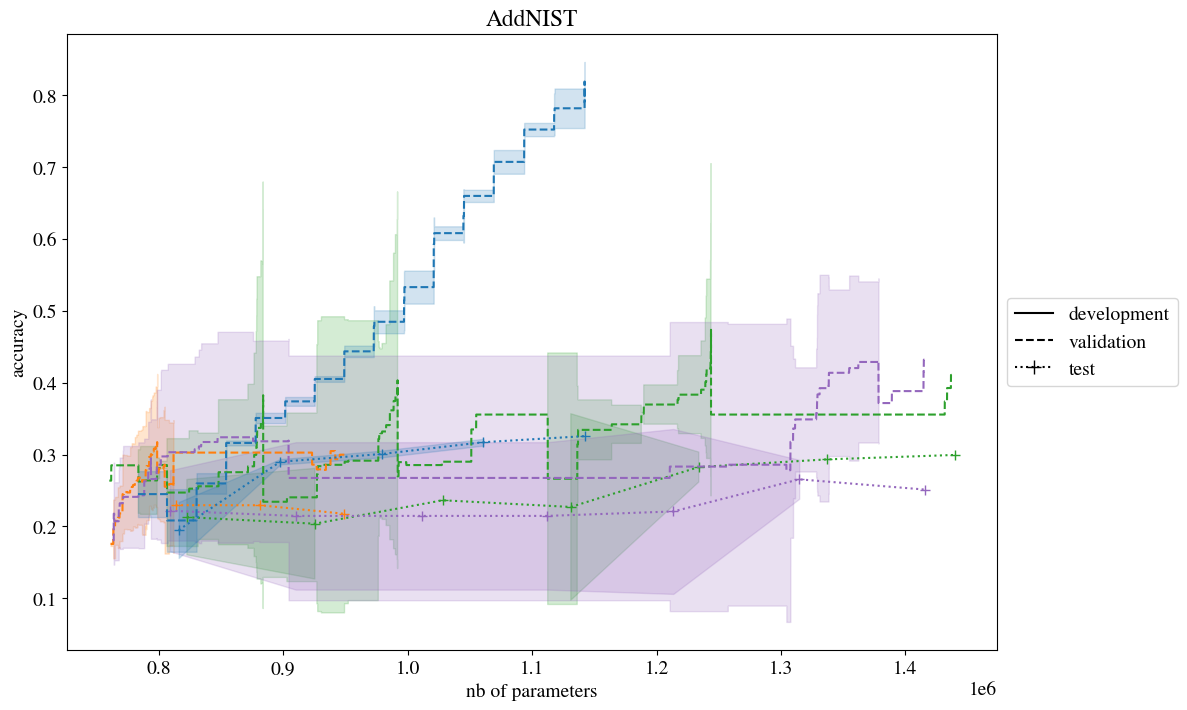

In [61]:
fig, ax1 = plt.subplots(figsize=(12,8))
for _name in interp_dev.keys():
    val_mean = np.nanmean(interp_val[_name], axis=0)
    sem = stats.sem(interp_val[_name], axis=0, nan_policy="omit")
    val_conf = 1.96 * sem
    ax1.plot(
        param_grid[_name][crop:],
        val_mean[crop:],
        color=colors[_name],
        # label=_name,
        linestyle="--",
    )
    ax1.fill_between(
        param_grid[_name][crop:],
        val_mean[crop:] - val_conf[crop:],
        val_mean[crop:] + val_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )
    
    test_mean = np.nanmean(interp_test[_name], axis=0)
    sem = stats.sem(interp_test[_name], axis=0, nan_policy="omit")
    test_conf = 1.96 * sem
    ax1.plot(
        param_grid_test[_name][crop:],
        test_mean[crop:],
        color=colors[_name],
        # label=_name,
        markersize=7,
        linestyle=":",
        marker="+",
    )
    ax1.fill_between(
        param_grid_test[_name][crop:],
        test_mean[crop:] - test_conf[crop:],
        test_mean[crop:] + test_conf[crop:],
        color=colors[_name],
        alpha=0.2,
    )



myHandle = [
    Line2D([], [], color="k", markersize=10, linestyle="-"),
    Line2D([], [], color="k", markersize=10, linestyle="--"),
    Line2D([], [], color="k", markersize=10, linestyle=":", marker="+"),
]

legend(ax1, extra_lines=myHandle, extra_labels=["development", "validation", "test"])
plt.xlabel("nb of parameters")
plt.ylabel("accuracy")
plt.title("AddNIST")
plt.show()

# ToDo

### Zoomed information

NameError: name 'run_info' is not defined

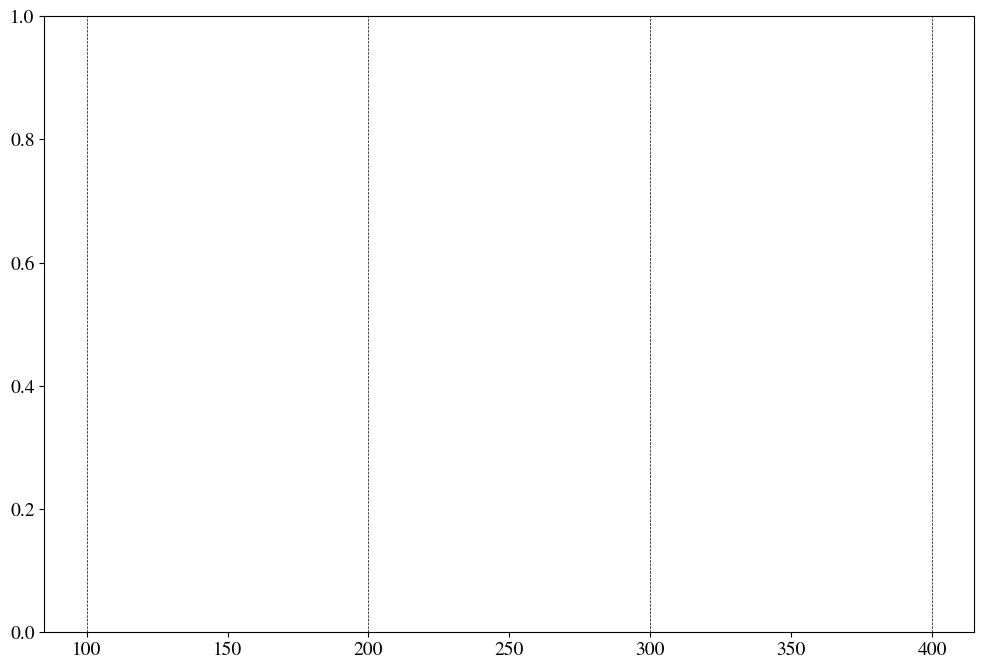

In [40]:
crop = 100  # 00
crop_end = 500
fig, ax1 = plt.subplots(figsize=(12, 8))
# ax2 = ax1.twinx()

[
    plt.axvline(x=v, linestyle="--", color="k", label="growth__", lw=0.5)
    for v in range(crop, crop_end, 100)
]
for name in run_info.keys():
    # ax1.plot(list(run_info['Intermediate training/dev loss'][i].keys())[crop:], list(run_info['Intermediate training/dev loss'][i].values())[crop:], "-", color=colors[i], label=f"{run_info['name'][i]}")
    # ax1.plot(list(run_info['Intermediate training/val loss'][i].keys())[crop:], list(run_info['Intermediate training/val loss'][i].values())[crop:], ":", color=colors[i], label=f"{run_info['name'][i]}")
    ax1.plot(
        list(run_info[name]["Intermediate training/dev accuracy"].keys())[crop:crop_end],
        list(run_info[name]["Intermediate training/dev accuracy"].values())[crop:crop_end],
        "-",
        color=colors[name[:-2]],
        label=f"{name}",
    )
    ax1.plot(
        list(run_info[name]["Intermediate training/val accuracy"].keys())[crop:crop_end],
        list(run_info[name]["Intermediate training/val accuracy"].values())[crop:crop_end],
        ":",
        color=colors[name[:-2]],
        label=f"{name}",
    )
    epoch_len = list(run_info[name]["test accuracy"].keys())[0]
    crop_acc = int(crop / epoch_len)
    ax1.scatter(
        list(run_info[name]["test accuracy"].keys())[crop_acc:],
        list(run_info[name]["test accuracy"].values())[crop_acc:],
        marker="*",
        color=colors[name[:-2]],
        label="test accuracy__",
        # linewidths=5
    )
ax1.set_ylabel("accuracy")
# ax2.set_ylabel("accuracy")
ax1.set_xlabel("epochs")
# ax1.set_xscale("log")




myHandle = [
    Line2D([], [], color="k", markersize=10, linestyle="-"),
    Line2D([], [], color="k", markersize=10, linestyle=":"),
]  ##Create custom handles for 2nd legend
# l2 = ax1.legend(handles=myHandle, labels = ['development', 'validation'], bbox_to_anchor=(1.4,1)) ##Add 2nd legend

legend(ax1, ax2=None, extra_lines=myHandle, extra_labels=["development", "validation"], trim_labels=2)
plt.xlim(crop, crop_end)
plt.show()

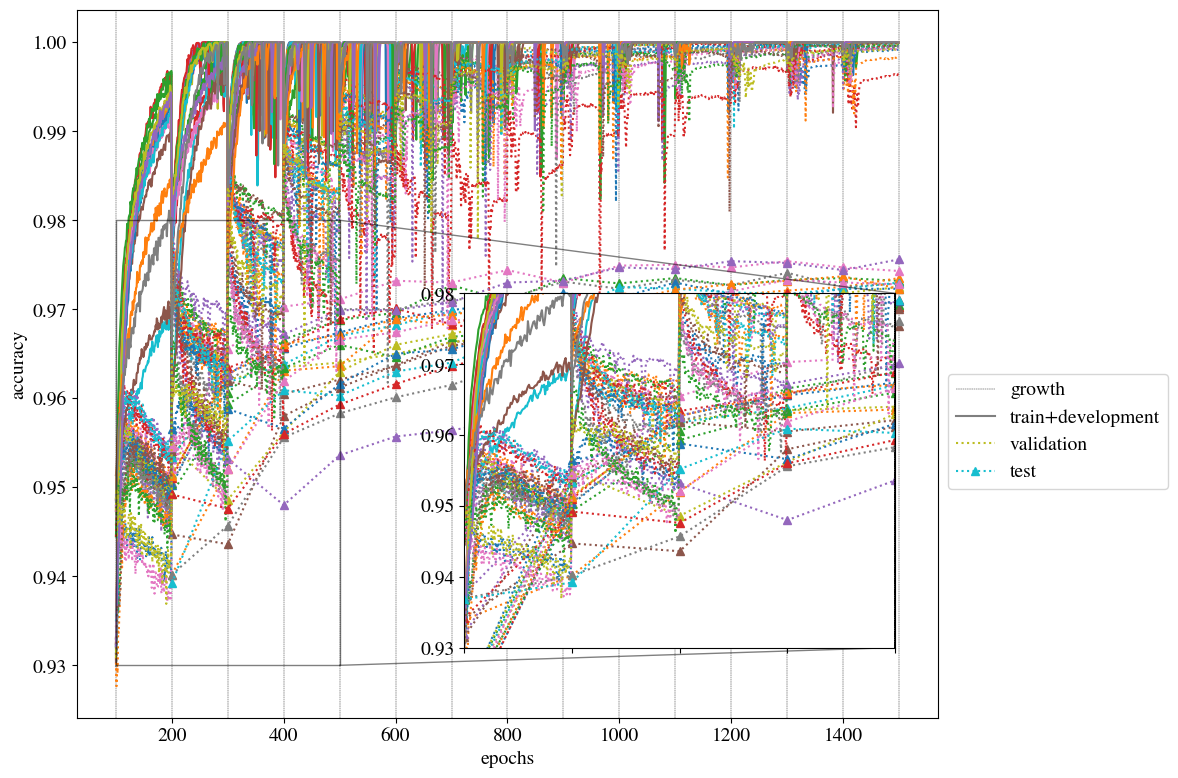

In [33]:
crop = 100  # 00
crop_end = 1_500
fig, ax1 = plt.subplots(figsize=(12, 8))

[
    ax1.axvline(x=v, linestyle="--", color="k", label="growth", lw=0.3)
    for v in range(crop, crop_end+1, 100)
]
for name in run_info.keys():
    ax1.plot(
        list(run_info[name]["Intermediate training/dev accuracy"].keys())[crop:crop_end],
        list(run_info[name]["Intermediate training/dev accuracy"].values())[crop:crop_end],
        "-",
        label=f"train+development",
    )
    ax1.plot(
        list(run_info[name]["Intermediate training/val accuracy"].keys())[crop:crop_end],
        list(run_info[name]["Intermediate training/val accuracy"].values())[crop:crop_end],
        ":",
        label=f"validation",
    )

    epoch_len = list(run_info[name]["test accuracy"].keys())[0]
    crop_start_acc, crop_end_acc = int(crop / epoch_len), int(crop_end / epoch_len)
    ax1.plot(
        list(run_info[name]["test accuracy"].keys())[crop_start_acc:crop_end_acc],
        list(run_info[name]["test accuracy"].values())[crop_start_acc:crop_end_acc],
        ":^",
        label="test",
    )

zoom_start = 100
zoom_end = 500

axins = ax1.inset_axes(
    (0.45, 0.1, 0.5, 0.5),
    xlim=(zoom_start, zoom_end),
    ylim=(0.93, 0.98),
    xticklabels=[],  # yticklabels=[]
)
for name in run_info.keys():
    axins.plot(
        list(run_info[name]["Intermediate training/dev accuracy"].keys())[zoom_start:zoom_end],
        list(run_info[name]["Intermediate training/dev accuracy"].values())[
            zoom_start:zoom_end
        ],
        "-",
    )
    axins.plot(
        list(run_info[name]["Intermediate training/val accuracy"].keys())[zoom_start:zoom_end],
        list(run_info[name]["Intermediate training/val accuracy"].values())[
            zoom_start:zoom_end
        ],
        ":",
    )
    axins.plot(
        list(run_info[name]["test accuracy"].keys()),
        list(run_info[name]["test accuracy"].values()),
        ":^",
    )
    [
        axins.axvline(x=v, linestyle="--", color="k", label="growth", lw=0.3)
        for v in range(500, 3_000, 500)
    ]

ax1.indicate_inset_zoom(axins, edgecolor="black")

legend(ax1, loc="upper left")  # , None, myHandle, ["development", "validation"])
# plt.xlim(500, 3_000)
ax1.set_ylabel("accuracy")
ax1.set_xlabel("epochs")
# ax1.set_xscale("log")
plt.title("")
plt.tight_layout()
# plt.savefig("temp/plots/mnist_growth.eps", format="eps")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


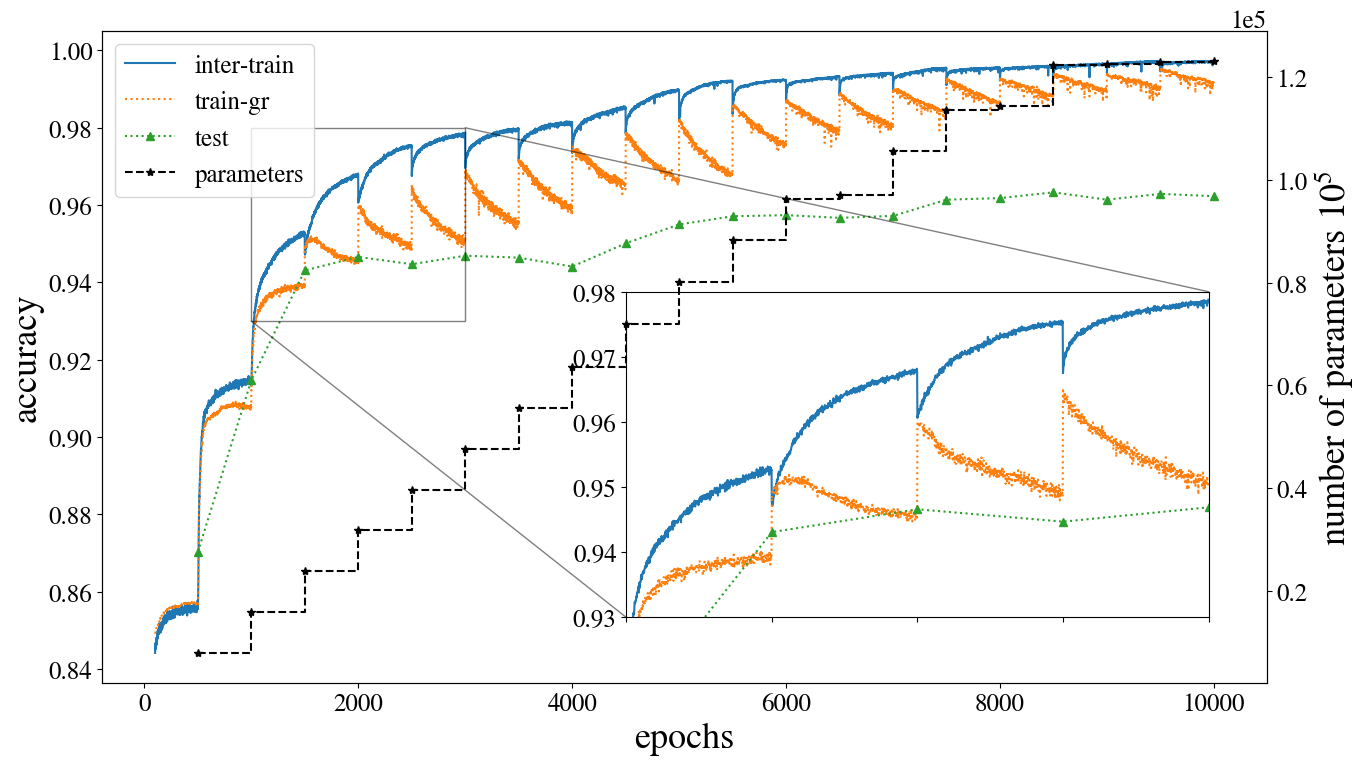

In [117]:
plt.rcParams.update({"font.size": 18})

crop = 100  # 00
crop_end = 10_000
fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

# [ax1.axvline(x = v, linestyle="--", color = 'k', label = 'growth', lw=.3) for v in range(500, 3_000, 500)]
for i in range(len(run_info["name"])):
    ax1.plot(
        list(run_info["Intermediate training/dev accuracy"][i].keys())[crop:crop_end],
        list(run_info["Intermediate training/dev accuracy"][i].values())[crop:crop_end],
        "-",
        label=f"inter-train",
    )
    ax1.plot(
        list(run_info["Intermediate training/val accuracy"][i].keys())[crop:crop_end],
        list(run_info["Intermediate training/val accuracy"][i].values())[crop:crop_end],
        ":",
        label=f"train-gr",
    )

    epoch_len = list(run_info["test accuracy"][i].keys())[0]
    crop_start_acc, crop_end_acc = int(crop / epoch_len), int(crop_end / epoch_len)
    ax1.plot(
        list(run_info["test accuracy"][i].keys())[crop_start_acc:crop_end_acc],
        list(run_info["test accuracy"][i].values())[crop_start_acc:crop_end_acc],
        ":^",
        label="test",
    )

    ax2.step(
        list(run_info["complexity/nb of parameters"][i].keys())[
            crop_start_acc:crop_end_acc
        ],
        list(run_info["complexity/nb of parameters"][i].values())[
            crop_start_acc:crop_end_acc
        ],
        "--*k",
        where="post",
        label="parameters",
    )

zoom_start = 1_000
zoom_end = 3_000

axins = ax1.inset_axes(
    (0.45, 0.1, 0.5, 0.5),
    xlim=(zoom_start, zoom_end),
    ylim=(0.93, 0.98),
    xticklabels=[],  # yticklabels=[]
)
axins.plot(
    list(run_info["Intermediate training/dev accuracy"][i].keys())[zoom_start:zoom_end],
    list(run_info["Intermediate training/dev accuracy"][i].values())[
        zoom_start:zoom_end
    ],
    "-",
)
axins.plot(
    list(run_info["Intermediate training/val accuracy"][i].keys())[zoom_start:zoom_end],
    list(run_info["Intermediate training/val accuracy"][i].values())[
        zoom_start:zoom_end
    ],
    ":",
)
axins.plot(
    list(run_info["test accuracy"][i].keys()),
    list(run_info["test accuracy"][i].values()),
    ":^",
)
# [axins.axvline(x = v, linestyle="--", color = 'k', label = 'growth', lw=.3) for v in range(500, 3_000, 500)]

ax1.indicate_inset_zoom(axins, edgecolor="black")

legend(ax1, ax2, loc="upper left")  # , None, myHandle, ["development", "validation"])
# plt.xlim(500, 3_000)
ax1.set_ylabel("accuracy", fontsize=26)
ax1.set_xlabel("epochs", fontsize=26)
# ax1.set_xscale("log")
ax2.set_ylabel(f"number of parameters $10^5$", fontsize=26)
ax2.ticklabel_format(axis="y", scilimits=(-3, 3))
# ax2.set_yscale("log")
plt.title("")
plt.tight_layout()
plt.savefig("temp/plots/mnist_growth_params_wide.eps", format="eps")
plt.show()

plt.rcParams.update({"font.size": 14})

### GPU hours

In [93]:
print(run_info["duration (h)"])

24.160728888888887


dev accuracy 0.99725
test accuracy 0.9623
duration (s) 24084.768
duration (h) 6.690213333333333
duration (d) 0.2787588888888889
duration (d) for 7 hours 0.2916666666666667


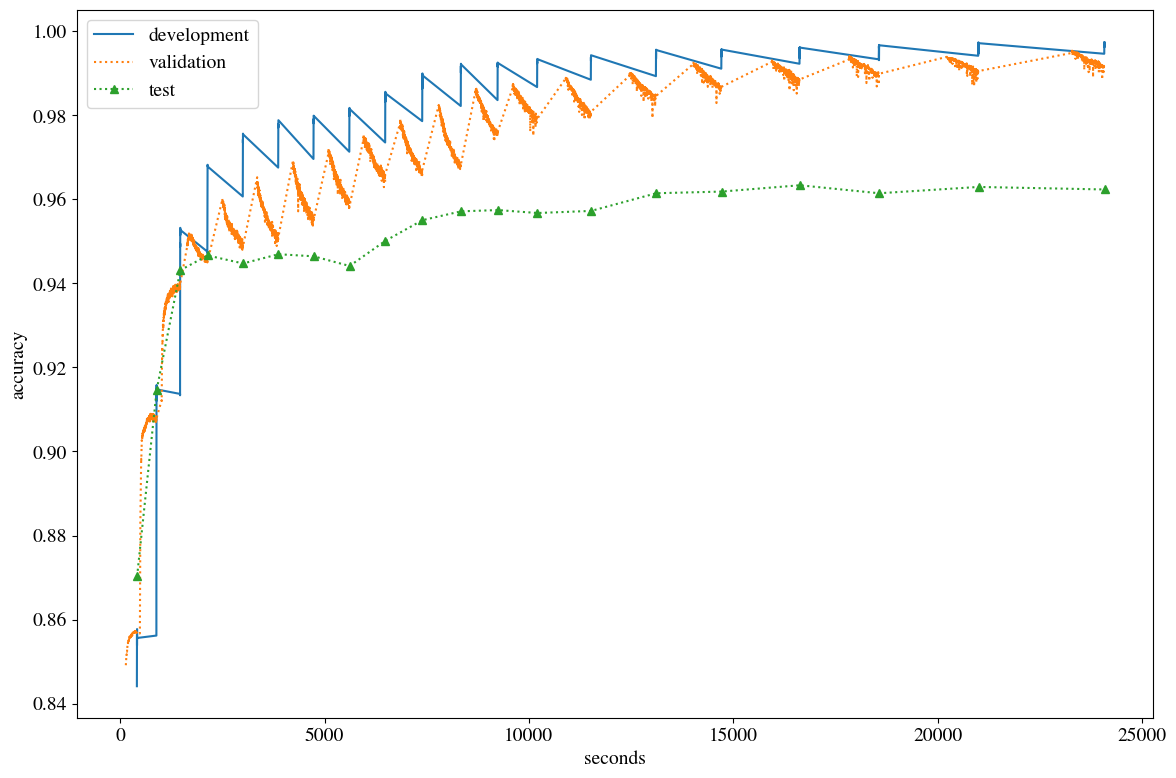

In [94]:
crop = 100  # 00
crop_end = 10_000
fig, ax1 = plt.subplots(figsize=(12, 8))

# [ax1.axvline(x = v, linestyle="--", color = 'k', label = 'growth', lw=.3) for v in range(500, 3_000, 500)]
for i in range(len(run_info_t["name"])):
    ax1.plot(
        list(run_info_t["Intermediate training/dev accuracy"][i].keys())[crop:crop_end],
        list(run_info_t["Intermediate training/dev accuracy"][i].values())[
            crop:crop_end
        ],
        "-",
        label=f"development",
    )
    ax1.plot(
        list(run_info_t["Intermediate training/val accuracy"][i].keys())[crop:crop_end],
        list(run_info_t["Intermediate training/val accuracy"][i].values())[
            crop:crop_end
        ],
        ":",
        label=f"validation",
    )

    epoch_len = list(run_info["test accuracy"][i].keys())[0]
    crop_start_acc, crop_end_acc = int(crop / epoch_len), int(crop_end / epoch_len)
    ax1.plot(
        list(run_info_t["test accuracy"][i].keys())[crop_start_acc:crop_end_acc],
        list(run_info_t["test accuracy"][i].values())[crop_start_acc:crop_end_acc],
        ":^",
        label="test",
    )

print(
    "dev accuracy",
    list(run_info_t["Intermediate training/dev accuracy"][i].values())[crop_end - 1],
)
print("test accuracy", list(run_info_t["test accuracy"][i].values())[crop_end_acc - 1])
print(
    "duration (s)",
    list(run_info_t["Intermediate training/dev accuracy"][i].keys())[crop_end - 1],
)
print(
    "duration (h)",
    list(run_info_t["Intermediate training/dev accuracy"][i].keys())[crop_end - 1]
    / 3_600,
)
print(
    "duration (d)",
    list(run_info_t["Intermediate training/dev accuracy"][i].keys())[crop_end - 1]
    / 3_600
    / 24,
)
print("duration (d) for 7 hours", 7 / 24)
# zoom_start = 1_000
# zoom_end = 3_000

# axins = ax1.inset_axes(
#     (0.45, 0.1, 0.5, 0.5),
#     xlim=(zoom_start, zoom_end), ylim=(0.93, 0.98), xticklabels=[], #yticklabels=[]
#     )
# axins.plot(list(run_info_t['Intermediate training/dev accuracy'][i].keys())[zoom_start:zoom_end], list(run_info_t['Intermediate training/dev accuracy'][i].values())[zoom_start:zoom_end], "-")
# axins.plot(list(run_info_t['Intermediate training/val accuracy'][i].keys())[zoom_start:zoom_end], list(run_info_t['Intermediate training/val accuracy'][i].values())[zoom_start:zoom_end], ":")
# axins.plot(list(run_info_t['test accuracy'][i].keys()), list(run_info_t['test accuracy'][i].values()), ":^")
# [axins.axvline(x = v, linestyle="--", color = 'k', label = 'growth', lw=.3) for v in range(500, 3_000, 500)]

# ax1.indicate_inset_zoom(axins, edgecolor="black")

legend(ax1, loc="upper left")  # , None, myHandle, ["development", "validation"])
# plt.xlim(500, 3_000)
ax1.set_ylabel("accuracy")
ax1.set_xlabel("seconds")
# ax1.set_xscale("log")
plt.title("")
plt.tight_layout()
plt.show()

### Baseline graphs

In [95]:
run_info.keys()

dict_keys(['duration (ms)', 'duration (s)', 'duration (h)', 'name', 'growth train loss', 'growth dev loss', 'dev loss', 'growth val loss', 'val loss', 'test loss', 'growth train accuracy', 'growth dev accuracy', 'dev accuracy', 'growth val accuracy', 'val accuracy', 'test accuracy', 'system/system_memory_usage_megabytes', 'system/disk_usage_megabytes', 'system/disk_available_megabytes', 'system/gpu_0_memory_usage_megabytes', 'system/gpu_0_power_usage_watts', 'system/gpu_1_memory_usage_megabytes', 'system/gpu_1_power_usage_watts', 'system/gpu_2_memory_usage_megabytes', 'system/gpu_2_power_usage_watts', 'system/gpu_3_memory_usage_megabytes', 'system/gpu_3_power_usage_watts', 'Intermediate training/val loss', 'Intermediate training/val accuracy', 'Intermediate training/dev loss', 'Intermediate training/dev accuracy', 'complexity/flops', 'complexity/activations', 'complexity/nb of parameters', 'codecarbon/duration', 'codecarbon/emissions', 'codecarbon/emissions_rate', 'codecarbon/cpu_power

In [96]:
final_acc_dev = (
    list(run_info["Intermediate training/dev accuracy"][i].values())[crop_end_acc - 1]
    * 100
)
final_acc_test = list(run_info["test accuracy"][i].values())[crop_end_acc - 1] * 100
final_nb_params = list(run_info["complexity/nb of parameters"][i].values())[
    crop_end_acc - 1
]
final_gpu_energy = list(run_info["codecarbon/gpu_energy"][i].values())[crop_end_acc - 1]
print(final_acc_dev, final_acc_test, final_nb_params, final_gpu_energy)

72.39750000000001 96.23 123200.0 0.06440821735986901


In [97]:
100 - final_acc_test

3.769999999999996

In [98]:
north_pre_nb_params = 784 * 250 + 250 * 200 + 200 * 10
north_pre_acc_test = 98
print(north_pre_acc_test, north_pre_nb_params)
north_select_nb_params = 784 * 800 + 800 * 70 + 70 * 10
north_select_acc_test = 98.25
print(north_select_acc_test, north_select_nb_params)

98 248000
98.25 683900


In [99]:
layers2_300_distortions_nb_params = 784 * 300 + 300 * 10
layers2_300_distortions_acc_test = 100 - 3.6
print(layers2_300_distortions_nb_params, layers2_300_distortions_acc_test)
layers2_300_nb_params = 784 * 300 + 300 * 10
layers2_300_acc_test = 100 - 4.7
print(layers2_300_nb_params, layers2_300_acc_test)
layers2_1000_distortions_nb_params = 784 * 1000 + 1000 * 10
layers2_1000_distortions_acc_test = 100 - 3.8
print(layers2_1000_distortions_nb_params, layers2_1000_distortions_acc_test)
layers2_1000_nb_params = 784 * 1000 + 1000 * 10
layers2_1000_acc_test = 100 - 4.5
print(layers2_1000_nb_params, layers2_1000_acc_test)
layers3_300_100_nb_params = 784 * 300 + 300 * 100 + 100 * 10
layers3_300_100_acc_test = 100 - 3.05
print(layers3_300_100_nb_params, layers3_300_100_acc_test)

238200 96.4
238200 95.3
794000 96.2
794000 95.5
266200 96.95


In [100]:
crop_end_acc

20

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


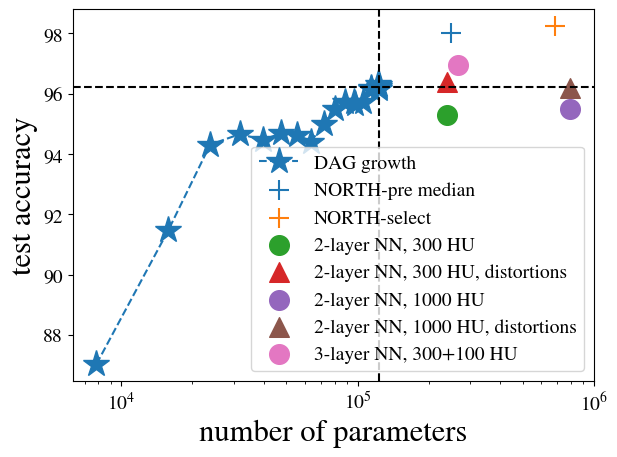

In [121]:
fig, ax1 = plt.subplots()
size = 200

plt.plot(
    list(run_info_t["complexity/nb of parameters"][i].values())[:20],
    list(map(lambda x: x * 100, run_info_t["test accuracy"][i].values()))[:20],
    "--*",
    markersize=size / 10,
    label="DAG growth",
)
# plt.scatter(final_nb_params, final_acc_test, marker="*", label="DAG")
plt.axvline(final_nb_params, linestyle="--", c="black")
plt.axhline(final_acc_test, linestyle="--", c="black")

plt.scatter(
    north_pre_nb_params,
    north_pre_acc_test,
    marker="+",
    s=size,
    label="NORTH-pre median",
)
plt.scatter(
    north_select_nb_params,
    north_select_acc_test,
    marker="+",
    s=size,
    label="NORTH-select",
)

plt.scatter(
    layers2_300_nb_params, layers2_300_acc_test, s=size, label="2-layer NN, 300 HU"
)
plt.scatter(
    layers2_300_distortions_nb_params,
    layers2_300_distortions_acc_test,
    marker="^",
    s=size,
    label="2-layer NN, 300 HU, distortions",
)
plt.scatter(
    layers2_1000_nb_params, layers2_1000_acc_test, s=size, label="2-layer NN, 1000 HU"
)
plt.scatter(
    layers2_1000_distortions_nb_params,
    layers2_1000_distortions_acc_test,
    marker="^",
    s=size,
    label="2-layer NN, 1000 HU, distortions",
)
plt.scatter(
    layers3_300_100_nb_params,
    layers3_300_100_acc_test,
    s=size,
    label="3-layer NN, 300+100 HU",
)

legend(ax1)
plt.xlabel("number of parameters", fontsize=22)
plt.ylabel("test accuracy", fontsize=22)
plt.xscale("log")
plt.tight_layout()
plt.savefig("temp/plots/mnist_baselines.eps", format="eps")
plt.show()

### Split loss and accuracy

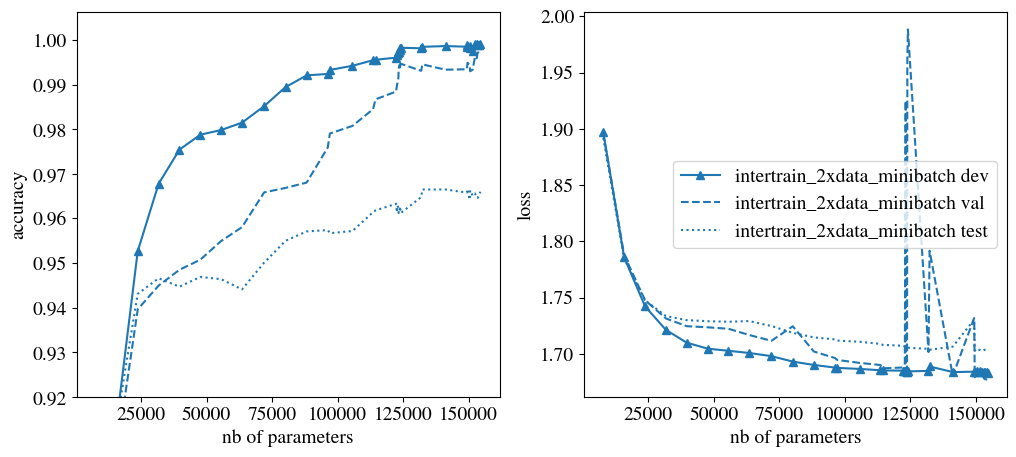

In [102]:
crop = None
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
for i in range(len(run_info["name"])):
    ax1.plot(
        list(run_info["complexity/nb of parameters"][i].values())[:crop],
        list(run_info["dev accuracy"][i].values())[:crop],
        "-^",
        color=colors[i],
        label=f'{run_info["name"][i]} dev',
    )
    ax1.plot(
        list(run_info["complexity/nb of parameters"][i].values())[:crop],
        list(run_info["val accuracy"][i].values())[:crop],
        "--",
        color=colors[i],
        label=f'{run_info["name"][i]} val',
    )
    ax1.plot(
        list(run_info["complexity/nb of parameters"][i].values())[:crop],
        list(run_info["test accuracy"][i].values())[:crop],
        ":",
        color=colors[i],
        label=f'{run_info["name"][i]} test',
    )

    ax2.plot(
        list(run_info["complexity/nb of parameters"][i].values())[:crop],
        list(run_info["dev loss"][i].values())[:crop],
        "-^",
        color=colors[i],
        label=f'{run_info["name"][i]} dev',
    )
    ax2.plot(
        list(run_info["complexity/nb of parameters"][i].values())[:crop],
        list(run_info["val loss"][i].values())[:crop],
        "--",
        color=colors[i],
        label=f'{run_info["name"][i]} val',
    )
    ax2.plot(
        list(run_info["complexity/nb of parameters"][i].values())[:crop],
        list(run_info["test loss"][i].values())[:crop],
        ":",
        color=colors[i],
        label=f'{run_info["name"][i]} test',
    )
ax1.set_ylabel("accuracy")
ax2.set_ylabel("loss")
ax1.set_xlabel("nb of parameters")
ax2.set_xlabel("nb of parameters")
# ax1.set_xscale("log")
ax1.set_ylim(bottom=0.92)
legend(ax1, ax2)
plt.show()

### GPU and FLOPS

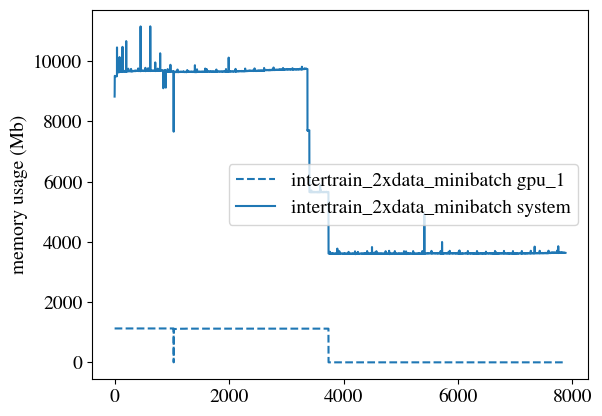

In [103]:
crop = None
fig, ax1 = plt.subplots()
for i in range(len(run_info["name"])):
    # ax1.plot(list(run_info['system/gpu_0_memory_usage_megabytes'][i].values())[:crop], '-', color=colors[i], label=f'{run_info["name"][i]} gpu_0')
    ax1.plot(
        list(run_info["system/gpu_1_memory_usage_megabytes"][i].values())[:crop],
        "--",
        color=colors[i],
        label=f'{run_info["name"][i]} gpu_1',
    )
    ax1.plot(
        list(run_info["system/system_memory_usage_megabytes"][i].values())[:crop],
        "-",
        color=colors[i],
        label=f'{run_info["name"][i]} system',
    )
ax1.set_ylabel("memory usage (Mb)")
# ax1.set_xlabel('nb of parameters')
# ax1.set_xscale("log")
legend(ax1)
plt.show()

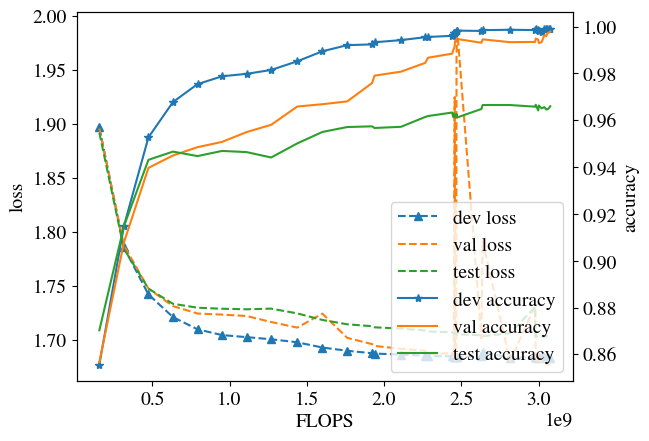

In [104]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
for i in range(len(run_info["name"])):
    ax1.plot(
        run_info["complexity/flops"][i].values(),
        run_info["dev loss"][i].values(),
        "--^",
        color=colors[0],
        label="dev loss",
    )
    ax1.plot(
        run_info["complexity/flops"][i].values(),
        run_info["val loss"][i].values(),
        "--",
        color=colors[1],
        label="val loss",
    )
    ax1.plot(
        run_info["complexity/flops"][i].values(),
        run_info["test loss"][i].values(),
        "--",
        color=colors[2],
        label="test loss",
    )
    ax2.plot(
        run_info["complexity/flops"][i].values(),
        run_info["dev accuracy"][i].values(),
        "-*",
        color=colors[0],
        label="dev accuracy",
    )
    ax2.plot(
        run_info["complexity/flops"][i].values(),
        run_info["val accuracy"][i].values(),
        color=colors[1],
        label="val accuracy",
    )
    ax2.plot(
        run_info["complexity/flops"][i].values(),
        run_info["test accuracy"][i].values(),
        color=colors[2],
        label="test accuracy",
    )
ax1.set_ylabel("loss")
ax2.set_ylabel("accuracy")
ax1.set_xlabel("FLOPS")
legend(ax1, ax2)
plt.show()

In [105]:
print(run_info_t["system/gpu_0_memory_usage_megabytes"][0])
print(run_info_t["dev loss"][0])

{10.308: 653.1, 20.698: 779.0, 30.87: 1160.6, 41.03: 1351.5, 51.197: 1351.5, 61.317: 1477.3, 71.529: 1477.3, 81.676: 1477.3, 91.916: 1605.2, 102.093: 1605.2, 112.228: 1605.2, 122.365: 1605.2, 132.533: 1605.2, 142.684: 1605.2, 152.81: 1605.2, 163.066: 1605.2, 173.217: 1605.2, 183.422: 1605.2, 193.553: 1605.2, 203.693: 1605.2, 213.898: 1605.2, 224.099: 1605.2, 234.293: 1605.2, 244.463: 1605.2, 254.642: 1605.2, 264.824: 1605.2, 275.029: 1605.2, 285.186: 1605.2, 295.381: 1605.2, 305.563: 1605.2, 315.744: 1605.2, 325.921: 1605.2, 336.094: 1605.2, 346.232: 1605.2, 356.368: 1605.2, 366.532: 1605.2, 376.741: 1605.2, 386.918: 1605.2, 397.072: 1605.2, 407.474: 1605.2, 417.615: 1605.2, 427.763: 1605.2, 437.963: 1952.3, 448.16: 1605.2, 458.387: 1605.2, 468.626: 1605.2, 478.922: 1605.2, 489.146: 1605.2, 499.345: 1605.2, 509.628: 1605.2, 519.864: 1605.2, 530.086: 1605.2, 540.295: 1605.2, 550.581: 1605.2, 560.809: 1605.2, 571.056: 1605.2, 581.254: 1605.2, 591.456: 1605.2, 602.012: 1605.2, 612.247: 16

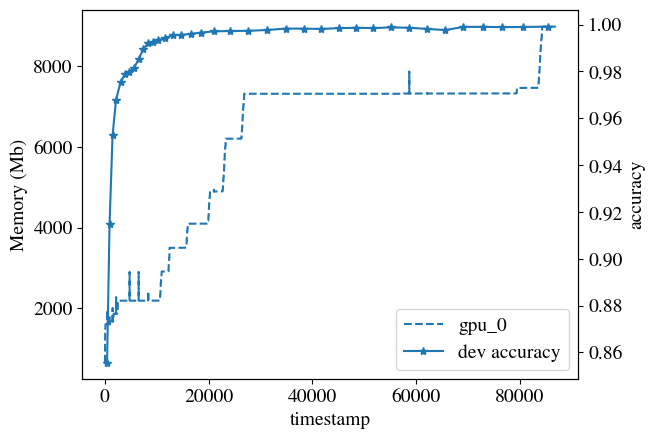

In [106]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
for i in range(len(run_info_t["name"])):
    ax1.plot(
        run_info_t["system/gpu_0_memory_usage_megabytes"][i].keys(),
        run_info_t["system/gpu_0_memory_usage_megabytes"][i].values(),
        "--",
        label="gpu_0",
    )
    # plt.plot(run_info_t['system/system_memory_usage_megabytes'][i].values(), '--', label='system')
    ax2.plot(
        run_info_t["dev accuracy"][i].keys(),
        run_info_t["dev accuracy"][i].values(),
        "-*",
        label="dev accuracy",
    )
ax1.set_ylabel("Memory (Mb)")
ax2.set_ylabel("accuracy")
ax1.set_xlabel("timestamp")
legend(ax1, ax2)
plt.show()

# End